## Исследование данных о российском кинопрокате

Заказчик этого исследования — Министерство культуры Российской Федерации.

Цели:
* Изучить рынок российского кинопроката и выявить текущие тренды. 
* Уделить внимание фильмам, которые получили государственную поддержку. 
* Ответить на вопрос, насколько такие фильмы интересны зрителю.

### План исследования

**Шаг 1. Откройте файлы с данными и объедините их в один датафрейм**

Объединить данные таким образом, чтобы все объекты из датасета `mkrf_movies` обязательно вошли в получившийся датафрейм.

**Шаг 2. Предобработка данных**

- Проверить типы данных в датафрейме и преобразуйте там, где это необходимо.
- Изучить пропуски в датафрейме. Объяснить, почему заполнили пропуски определённым образом или почему не стали это делать.
- Проверить, есть ли в данных дубликаты. Опишите причины, которые могли повлиять на появление дублей.
- Изучить столбцы, которые содержат категориальные значения:
    - Посмотреть, какая общая проблема встречается почти во всех категориальных столбцах;
    - Исправить проблемные значения в поле `type`.
- Изучить столбцы, которые хранят количественные значения. Проверить, обнаружились ли в таких столбцах подозрительные данные. Как с такими данными лучше поступить?
- Добавьте новые столбцы:
    - Создать столбец с информацией о годе проката. Выделите год из даты премьеры фильма;
    - Создать два столбца: с именем и фамилией главного режиссёра и основным жанром фильма. В столбцы войдут первые значения из списка режиссёров и жанров соответственно;
    - Посчитать, какую долю от общего бюджета фильма составляет государственная поддержка.

**Шаг 3. Проведите исследовательский анализ данных**

- Посмотреть, сколько фильмов выходило в прокат каждый год. Обратите внимание, что данные о прокате в кинотеатрах известны не для всех фильмов. Посчитайте, какую долю составляют фильмы с указанной информацией о прокате в кинотеатрах. Проанализируйте, как эта доля менялась по годам. Сделайте вывод о том, какой период полнее всего представлен в данных.
- Изучить, как менялась динамика проката по годам. В каком году сумма сборов была минимальной? А максимальной?
- С помощью сводной таблицы посчитать среднюю и медианную сумму сборов для каждого года. Сравнить значения и сделать выводы.
- Определить, влияет ли возрастное ограничение аудитории («6+», «12+», «16+», «18+» и т. д.) на сборы фильма в прокате в период с 2015 по 2019 год? Фильмы с каким возрастным ограничением собрали больше всего денег в прокате? Меняется ли картина в зависимости от года? Если да, предположите, с чем это может быть связано.

**Шаг 4. Исследовать фильмы, которые получили государственную поддержку**


**Шаг 5. Написать общий вывод**

### Шаг 1. Откройте файлы с данными и объедините их в один датафрейм. 

Объедините данные таким образом, чтобы все объекты из датасета `mkrf_movies` обязательно вошли в получившийся датафрейм. 

<div id="accordion">
    <div class="card">
        <div class="card-header" id="headingThree">
            <button class="btn btn-link collapsed" data-toggle="collapse" data-target="#collapseHint_0" aria-expanded="false" aria-controls="collapseHint_0">Подсказка</button>
        </div>
        <div id="collapseHint_0" class="collapse" aria-labelledby="headingThree" data-parent="#accordion">
            <div class="card-body">
Обратите внимание на тип данных столбца, по которому будете соединять датафреймы. Тип данных этих столбцов должен быть одинаковым в обоих датафреймах.
            </div>
        </div>
    </div>
</div>

In [1]:
# Импортируем необходимые библиотеки и настройки 

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import warnings

# Отключаем предупреждения
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.2f}'.format) #отключаем экспоненциальный формат чисел
pd.set_option('display.max_rows', None) # вывод результатов без сокращения строк

In [2]:
# Прочитаем датасеты
movies = pd.read_csv('/datasets/mkrf_movies.csv')
shows = pd.read_csv('/datasets/mkrf_shows.csv')

# Настроим отображение всех столбцов
pd.set_option('display.max_columns', None)

In [3]:
# Ознакомимся с таблицей movies
movies.head()

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres
0,Открытый простор,221048915,2015-11-27T12:00:00.000Z,Художественный,"Тачстоун Пикчерз, Кобальт Пикчерз, Бикон Пикче...",США,Кевин Костнер,"Дэвид Валдес, Кевин Костнер, Джейк Эбертс",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,7.2,"боевик,драма,мелодрама"
1,Особо важное задание,111013716,2016-09-13T12:00:00.000Z,Художественный,"Киностудия ""Мосфильм""",СССР,Е.Матвеев,NaN,«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,6.6,"драма,военный"
2,Особо опасен,221038416,2016-10-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"
3,Особо опасен,221026916,2016-06-10T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"
4,Особо опасен,221030815,2015-07-29T12:00:00.000Z,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.8,"фантастика,боевик,триллер"


In [4]:
# Посмотрим информацию о таблице movies
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7486 entries, 0 to 7485
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7486 non-null   object 
 1   puNumber               7486 non-null   object 
 2   show_start_date        7486 non-null   object 
 3   type                   7486 non-null   object 
 4   film_studio            7468 non-null   object 
 5   production_country     7484 non-null   object 
 6   director               7477 non-null   object 
 7   producer               6918 non-null   object 
 8   age_restriction        7486 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 6510 non-null   object 
dtypes: f

In [5]:
# Ознакомимся с таблицей shows
shows.head()

,puNumber,box_office
0,111000113,2450.00
1,111000115,61040.00
2,111000116,153030013.40
3,111000117,12260956.00
4,111000118,163684057.79


In [6]:
# Посмотрим информацию о таблице shows
shows.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3158 entries, 0 to 3157
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   puNumber    3158 non-null   int64  
 1   box_office  3158 non-null   float64
dtypes: float64(1), int64(1)
memory usage: 49.5 KB


В таблице movies (данные о прокатных удостоверениях) - 7486 записей, в таблице shows (данные о прокате в российских кинотеатрах) - 3158. Таблицы имеют общее поле - puNumber (номер прокатного удостоверения), в таблице movies это поле со строковым форматом данных, в таблице shows - c целочисленным. В описаниях датасета указано, что у одного фильма может быть несколько прокатных удостоверний. Этим объясняется почему количество строк в таблице movies и shows отличаются больше чем в два раза.

In [7]:
# Изменим тип данных в столбце puNumber с int на str для того, чтобы объеденить с таблицей movies
shows['puNumber'] = shows['puNumber'].astype('str')

In [8]:
# Соединим два датасета по полю puNumber, так чтоб все строки из movies остались
data = movies.merge(shows, on='puNumber', how='left')

In [9]:
# Проверим объединенный датасет
data.sample(5)

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
6604,Семья по-быстрому,121031918,2019-01-24T12:00:00.000Z,Художественный,Парамаунт Пикчерз,США,Шон Андерс,"Шон Андерс, Стивен Левинсон, Джон Моррис",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,7.4,"драма,комедия",87382668.68
1632,Королевы ринга,121020813,2013-07-29T12:00:00.000Z,Художественный,"Каре Продюксьон, Ля Пти Рьен, Оранж Студио, Эм...",Франция,Жан-Марк Рудницкий,"Фабрис Голдштейн, Тома Лангманн, Антуан Рейн",«16+» - для детей старше 16 лет,NaN,NaN,NaN,NaN,5.9,"комедия,спорт",NaN
6543,Я больше с собой не спорю,112024618,2018-12-20T12:00:00.000Z,Художественный,"ООО ""ПТ Театр ""Киноспектакль"" О.Лещинера""",Россия,О.Лещинер,"О.Лещинер, О.Ракитянский",«12+» - для детей старше 12 лет,NaN,NaN,NaN,NaN,3.9,"документальный,биография",NaN
7145,Улётные букашки,124006019,2019-08-29T12:00:00.000Z,Анимационный,ИТСКАРТУН,Китай,Дэн Вэйфэн,"Юань Мэй, Ян Чжэньхуа, Ян Сюэцзюй",«6+» - для детей старше 6 лет,NaN,NaN,NaN,NaN,NaN,NaN,874071.00
1618,7 ящиков,121017713,2013-07-09T12:00:00.000Z,Художественный,Манеглиа Шембори Реализадорес,Парагвай,"Хуан Карлос Манеглиа, Тана Шембори","Росио Гальяно, Ричард Кареага",«18+» - запрещено для детей,NaN,NaN,NaN,NaN,6.2,"триллер,драма,криминал",NaN


In [10]:
# Проверим, что все строки из movies остались
movies.shape[0] == data.shape[0]

True

**Выводы по подготовке данных к анализу**

По заданию объединены два датасета. По условию необходимо было, чтобы все объекты из таблицы movies вошли в получившийся датафрейм - для это датафремы были объединены способом "left", то есть ко всем объектам таблицы movies (левая таблица) присоединялись объекты из таблицы shows на основании совпадения прокатного удостоверения. Этот способ как раз и позволяет выполнить поставленное условие.

### Шаг 2. Предобработка данных

#### Шаг 2.1. Проверьте типы данных

- Проверьте типы данных в датафрейме и преобразуйте их там, где это необходимо.

In [11]:
# Проверим типы данных в объединенном датасете
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 7486 entries, 0 to 7485
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  7486 non-null   object 
 1   puNumber               7486 non-null   object 
 2   show_start_date        7486 non-null   object 
 3   type                   7486 non-null   object 
 4   film_studio            7468 non-null   object 
 5   production_country     7484 non-null   object 
 6   director               7477 non-null   object 
 7   producer               6918 non-null   object 
 8   age_restriction        7486 non-null   object 
 9   refundable_support     332 non-null    float64
 10  nonrefundable_support  332 non-null    float64
 11  budget                 332 non-null    float64
 12  financing_source       332 non-null    object 
 13  ratings                6519 non-null   object 
 14  genres                 6510 non-null   object 
 15  box_

Необходимо изменить тип данных следующих столбцов:
* show_start_date - привести к типу даты
* ratings - привести к типу float

In [12]:
# Установим тип даты в столбце show_start_date
data['show_start_date'] = pd.to_datetime(data['show_start_date'], format='%Y-%m-%d')

In [13]:
# Установим тип float в столбце ratings
data['ratings'] = pd.to_numeric(data['ratings'], errors='coerce').astype('float64')

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Правильно выполнено задание по переводу типов данных колонок даты начала показа фильма и рейтинга.</font>

#### Шаг 2.2. Изучите пропуски в датафрейме

- Объясните, почему заполнили пропуски определённым образом или почему не стали этого делать.

In [14]:
# Комментарий ревьюера
temp = data.copy() # создаем копию датасета до преобразования
len(temp)

7486

In [15]:
# Посчитаем пропуски по столбцам датафрейма
data.isna().sum()

title                       0
puNumber                    0
show_start_date             0
type                        0
film_studio                18
production_country          2
director                    9
producer                  568
age_restriction             0
refundable_support       7154
nonrefundable_support    7154
budget                   7154
financing_source         7154
ratings                   996
genres                    976
box_office               4328
dtype: int64

* Больше всего пропусков по полям, связанным с господдержкой. Согласно условиям, это говорит о том, что большая часть данных представлена фильмами без господдержки. 

* Есть относительно небольшое количество пропусков по категориальным полям (студия, продюссер, жанр, страна). Пропуски в таких полям заполним "заглушкой" - "unknown"

In [16]:
# Заполним пропуски по полю director
data['director'] = data['director'].fillna('unknown')

In [17]:
# Заполним пропуски по полю producer
data['producer'] = data['producer'].fillna('unknown')

In [18]:
# Заполним пропуски по полю genres
data['genres'] = data['genres'].fillna('unknown')

In [19]:
# Заполним пропуски по полю film_studio
data['film_studio'] = data['film_studio'].fillna('unknown')

In [20]:
# Заполним пропуски по полю production_country
data['production_country'] = data['production_country'].fillna('unknown')

Количество пропусков по колонке financing_source соответствует количеству пропусков в колонке budget. Проверим какие источники указаны в датасете

In [21]:
# Проверим уникальные категории в столбце financing_source
data['financing_source'].unique()

array([nan, 'Министерство культуры', 'Фонд кино',
       'Министерство культуры, Фонд кино'], dtype=object)

Все источники связаны с государственным финансированием, следовательно пропущенные значения не связаны с источниками государственного финанисрования. Пропущенные значения заполним категорией "Частное финансирование"

In [22]:
data['financing_source'] = data['financing_source'].fillna('Частное финансирование')

Пропуски в поле box_office заполнять не будем. Пропусков в этом столбце около 50% - слишком большое количество для удаления. Заполнение средней или медианой может существенно исказить результаты исследования.

Разберемся с самой многочисленной группой пропусков - информацией о государственной поддержке фильмов. 

По всем трем столбцам количество пропусков совпадает. Заполним пропуски нулями, что будет говорить о том, что фильм снят **без участия господдержки** (согласно вводным к датасету)

In [23]:
# Заполним пропуски нулями
data['budget'] = data['budget'].fillna(0)
data['refundable_support'] = data['refundable_support'].fillna(0)
data['nonrefundable_support'] = data['nonrefundable_support'].fillna(0)

In [24]:
'''Заполним пропуски по полю ratings средним значением рейтинга по датасету
(с учетом замечания из раздела 1.3.6)
'''
# data['ratings'] = data['ratings'].fillna(data['ratings'].mean())

'Заполним пропуски по полю ratings средним значением рейтинга по датасету\n(с учетом замечания из раздела 1.3.6)\n'

In [25]:
# Еще раз проверим датасет после заполнения пропусков
data.isna().sum()

title                       0
puNumber                    0
show_start_date             0
type                        0
film_studio                 0
production_country          0
director                    0
producer                    0
age_restriction             0
refundable_support          0
nonrefundable_support       0
budget                      0
financing_source            0
ratings                   996
genres                      0
box_office               4328
dtype: int64

Осталось 4328 пропусков по полю с величиной кассовых сборов в кинотеатрах и 996 по полю рейтинга. По остальным полям пропуски заполнены, на данном этапе размер датасета не изменился. К проблеме пропусков по полю box_office вернемся в следующих разделах после проверки дубликатов.

#### Шаг 2.3. Изучите дубликаты в датафрейме
- Проверьте, есть ли в данных дубликаты. Опишите причины, которые могли повлиять на появление дублей.

In [26]:
# Проверим наличие полных дубликатов
data.duplicated().sum()

0

Полных дубликатов не обнаружено, все строки в датасете уникальны

In [27]:
# Проверим неявные дубликаты по паре title - puNumber
data.duplicated(subset=['title','puNumber'], keep=False).sum()

0

In [28]:
# Проверим дубликаты по полю puNumber
data.duplicated('puNumber', keep=False).sum()

4

In [29]:
#Найдено 4 дубликата по полю с номером прокатного удостоверения, посмотрим их
data[data.duplicated('puNumber', keep=False)]

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
4638,Как жениться и остаться холостым,221154310,2010-12-17 12:00:00+00:00,Художественный,"Ше Вам, Скрипт Ассосье, Тэ Фэ 1 Фильм Продюксь...",Франция,Эрик Лартиго,"Амандин Било, Алан Шаба",«16+» - для детей старше 16 лет,0.00,0.00,0.00,Частное финансирование,7.00,"мелодрама,комедия",NaN
4639,Иоанна - женщина на папском престоле /По роман...,221154310,2010-12-17 12:00:00+00:00,Художественный,"Константин Фильм, А Эр Ди Дегето Фильм, Дюне ...",Германия - Великобритания - Италия - Испания,Зенке Вортманн,"Оливер Бербен, Дорис Д.Хайнце, Фарук Элтан",«16+» - для детей старше 16 лет,0.00,0.00,0.00,Частное финансирование,7.60,"драма,мелодрама,история",NaN
5067,Анализируй это!,221054410,2010-05-25 12:00:00+00:00,Художественный,"Уорнер Бразерс, Вилладж Роудшоу Филмз ЛТД",США-Австралия,ХЭрольд Рэмис,"Джейн Розенталь, Пола Уейнстейн",«16+» - для детей старше 16 лет,0.00,0.00,0.00,Частное финансирование,7.40,"комедия,криминал",NaN
5068,Анализируй то!,221054410,2010-05-25 12:00:00+00:00,Художественный,"Уорнер Бразерс, Виллидж Роадшоу Пикчерз, Эн-Пи...",США,Гарольд Реймис,"Джейн Розенталь, Паул Уэйнстейн",«12+» - для детей старше 12 лет,0.00,0.00,0.00,Частное финансирование,6.80,"комедия,криминал",NaN


В первом случае - два совершенно разных фильма под одним удостоверением. Во втором - фильмы с похожим названием (отличается одна буква), с одной датой премьеры, но рейтинги отличаются, разное написание имени одного и того же режиссера, разные возрастные ограничения, разное наименование перечня студий. Эти дубли удалим.

In [30]:
# Удаление дублей по номеру прокатного удостоверения
data = data.drop_duplicates('puNumber')

In [31]:
# Проверим дубликаты по полю title
data.duplicated('title', keep=False).sum()

1271

Получилось почти 1300 дубликатов с названием фильма, но в описании к датасету было указано, что один фильм может иметь несколько прокатных удостоверений

In [32]:
# Посмотрим дубликаты по названию фильмов
data[data.duplicated('title', keep=False)].head(20)

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
2,Особо опасен,221038416,2016-10-10 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,0.00,0.00,0.00,Частное финансирование,6.80,"фантастика,боевик,триллер",NaN
3,Особо опасен,221026916,2016-06-10 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,0.00,0.00,0.00,Частное финансирование,6.80,"фантастика,боевик,триллер",NaN
4,Особо опасен,221030815,2015-07-29 12:00:00+00:00,Художественный,"Юниверсал Пикчерз, Кикстарт Продакшнз, Марк Пл...",США,Тимур Бекмамбетов,"Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит",«18+» - запрещено для детей,0.00,0.00,0.00,Частное финансирование,6.80,"фантастика,боевик,триллер",NaN
12,Малышка на миллион /По мотивам рассказов Ф.Х.Т...,221011415,2015-04-03 12:00:00+00:00,Художественный,"Уорнер Бразерс, Лейкшор Интертейнмент, Малпасо...",США,Клинт Иствуд,"Клинт Иствуд, Том Розенберг, Альберт С.Рудди, ...",«16+» - для детей старше 16 лет,0.00,0.00,0.00,Частное финансирование,8.10,"драма,спорт",NaN
26,Оружейный барон,221012515,2015-04-03 12:00:00+00:00,Художественный,"Вэ И Пэ Медиенфондс 3, Асендант Пикчерз, Сатур...",США - Франция - Турция,Эндрю Никкол,"Норман Голуайтли, Энди Грош, Николас Кейдж, Эн...",«18+» - запрещено для детей,0.00,0.00,0.00,Частное финансирование,7.70,"боевик,драма,криминал",NaN
33,Перелом,221006016,2016-02-09 12:00:00+00:00,Художественный,"Уорнер Бразерс, Нью Лайн Синема, Касл Рок Инте...",США-Германия,Грегори Хоблит,Чарльз Уэйнсток,«18+» - запрещено для детей,0.00,0.00,0.00,Частное финансирование,7.70,"триллер,драма,криминал",NaN
34,Мисс Поттер,221011915,2015-04-03 12:00:00+00:00,Художественный,"Феникс Пикчерз, Дэвид Киршнер Продакшнз, Айл о...",США - Великобритания,Крис Нунан,"Дэвид Киршнер, Майк Медэвой, Арнольд Мессер, К...",«12+» - для детей старше 12 лет,0.00,0.00,0.00,Частное финансирование,7.30,"драма,мелодрама,биография",NaN
37,Молчи в тряпочку,221012015,2015-04-03 12:00:00+00:00,Художественный,"Саммит Интертейнмент, Айл оф Мэн Филм, Эйзур Ф...",Великобритания,Найл Джонсон,"Мэтью Пэйн, Джулия Пэло",«18+» - запрещено для детей,0.00,0.00,0.00,Частное финансирование,7.10,"комедия,криминал",NaN
40,Алекс и Эмма,221005015,2015-02-25 12:00:00+00:00,Художественный,"Эскейп Артистс, Франчайз Пикчерз, Рейнер-Грэйс...",США,Роб Райнер,"Тодд Блэк, Элан Грейсман, Джереми Левен, Роб Р...",«16+» - для детей старше 16 лет,0.00,0.00,0.00,Частное финансирование,6.40,"мелодрама,комедия",NaN
41,Алекс и Эмма,221004616,2016-02-09 12:00:00+00:00,Художественный,"Эскейп Артистс, Франчайз Пикчерз, Рейнер-Грэйс...",США,Роб Райнер,"Тодд Блэк, Элан Грейсман, Джереми Левен, Роб Р...",«16+» - для детей старше 16 лет,0.00,0.00,0.00,Частное финансирование,6.40,"мелодрама,комедия",NaN


Из выборки видно, что у одного фильма действительно могут быть несколько разных прокатных удостоверения, наличие дублей по двум полям - "название-удостоверение" проверяли выше, таких случаев не обнаружено. Следовательно удалять такие дубли не будем.

In [33]:
# Провери на сколько сократился датасет после манипуляций с дублями
data.shape[0] - temp.shape[0]

-2

В итоге после проверки явных и неявных дублей было удалено 2 объекта из датафрейма.

#### Шаг 2.4. Изучите категориальные значения

- Посмотрите, какая общая проблема встречается почти во всех категориальных столбцах;
- Исправьте проблемные значения в поле `type`.

<div id="accordion">
    <div class="card">
        <div class="card-header" id="headingThree">
            <button class="btn btn-link collapsed" data-toggle="collapse" data-target="#collapseHint_1" aria-expanded="false" aria-controls="collapseHint_1">Подсказка</button>
        </div>
        <div id="collapseHint_1" class="collapse" aria-labelledby="headingThree" data-parent="#accordion">
            <div class="card-body">
В поле <code>type</code> есть несколько значений, у которых появился пробел в начале строки. Самый простой способ их «починить» -- использовать метод <a href="https://pandas.pydata.org/docs/reference/api/pandas.Series.str.strip.html#pandas.Series.str.strip">.str.strip</a>. Этот метод удаляет все пробелы, которые встречаются в начале и в конце строки. Применяют его таким образом:<br>
<code>df['type'].str.strip()</code>
            </div>
        </div>
    </div>
</div>

In [34]:
# Проверим значения по полю film_studio
data['film_studio'].value_counts()

Киностудия "Мосфильм"                                                                                                                                                                                                                                              341
ООО "Мульт в кино"                                                                                                                                                                                                                                                  57
Анимаккорд Лтд                                                                                                                                                                                                                                                      23
unknown                                                                                                                                                                                                            

В поле film_studio находится очень большое количество разных наименований студий, их совместное перечисление, указание форм собственности, вариации названий одних и тех же студий. Информация не унифицирована. Нормализация таких данных будет трудозатратна, а так как в соответствии с целями исследования наименование студии не является ключевым параметром, данные оставим как есть.

In [35]:
# Проверим значения по полю production_country
data['production_country'].value_counts()

США                                                                                                   2171
Россия                                                                                                1821
СССР                                                                                                   347
Франция                                                                                                301
Великобритания                                                                                         257
Италия                                                                                                 129
Германия                                                                                               110
США - Великобритания                                                                                    88
Япония                                                                                                  77
Испания                              

In [36]:
data['production_country'].unique()

array(['США', 'СССР', 'Франция', 'СССР, Венгрия',
       'Германия-Великобритания', 'Великобритания - Италия',
       'Чехословакия', 'США - Франция - Турция', 'Новая Зеландия',
       'Канада - Франция - Испания', 'США-Германия',
       'США - Великобритания', 'Великобритания', 'США - Германия',
       'Франция - Мексика - США', 'Россия, Казахстан, США',
       'СССР, Швеция', 'СССР, Франция, Англия, Куба, ГДР', 'Германия',
       'Великобритания-США-Германия-КНР',
       'СССР, ЧССР, Западный Берлин, ПНР', 'СССР, Италия', 'Гонконг, КНР',
       'США - Франция', 'США - Япония - Франция - Великобритания',
       'Гонконг - Сингапур - Таиланд - Великобритания', 'США-Канада',
       'Франция - Италия - Великобритания - США', 'Франция - США',
       'Ирландия-Великобритания-Германия', 'Чехия', 'США-Австралия',
       'СССР, Финляндия', 'США-Франция-Великобритания-Австрия',
       'США - Бельгия', 'США - Ирландия - Великобритания',
       'Великобритания - США',
       'Люксембург - Нидерл

Ситуация с качеством данных аналогична полю film_studio - огромное количество уникальных сочетаний, нормализовать данные проблематично.

In [37]:
# Проверим значения по полю director
data['director'].value_counts()

О.Семёнова                                                                                                                                                                                                                                           47
Д.Червяцов                                                                                                                                                                                                                                           17
Стивен Содерберг                                                                                                                                                                                                                                     17
Ридли Скотт                                                                                                                                                                                                                                          16
Тиль Шва

In [38]:
data['director'].unique()

array(['Кевин Костнер', 'Е.Матвеев', 'Тимур Бекмамбетов', ...,
       'Ник Пауэлл', 'А.Беляев', 'И.Трусов'], dtype=object)

In [39]:
# Проверим значения по полю producer
data['producer'].value_counts()

unknown                                                                                                                                                                                                                           568
П.Смирнов                                                                                                                                                                                                                          67
Олег Кузовков, Дмитрий Ловейко, Марина Ратина                                                                                                                                                                                      28
С.Сельянов                                                                                                                                                                                                                         18
Д.Ловейко, О.Кузовков                                                           

In [40]:
data['producer'].unique()

array(['Дэвид Валдес, Кевин Костнер, Джейк Эбертс', 'unknown',
       'Джим Лемли, Джейсон Нетер, Марк Е.Платт, Яйн Смит', ...,
       'Поппи Бегум, Ник Пойнц',
       'Джефф Боулер, Дэниэл Гродник, Луильо Руис, Брэт Саксон, Кирк Шоу',
       'Дженнифер Додж'], dtype=object)

In [41]:
# Проверим значения по полю age_restriction
data['age_restriction'].value_counts()

«16+» - для детей старше 16 лет           2850
«18+» - запрещено для детей               1605
«12+» - для детей старше 12 лет           1592
«0+» - для любой зрительской аудитории     811
«6+» - для детей старше 6 лет              626
Name: age_restriction, dtype: int64

По полю age_restriction данные нормализованы, 5 уникальных значений.

In [42]:
# Проверим значения по полю financing_source
data['financing_source'].value_counts()

Частное финансирование              7152
Министерство культуры                164
Фонд кино                            146
Министерство культуры, Фонд кино      22
Name: financing_source, dtype: int64

Так как и Министерство культуры и Фонд кино предполагают государственную поддержку кинематографа, предлагается объединить 3 категории "Министерство культуры", "Фонд кино", "Министерство культуры, Фонд кино" в одну "Министерство культуры и Фонд кино"

In [43]:
# Объеденим категории
data['financing_source'] = data['financing_source'].where(data['financing_source'] == 'Частное финансирование', 'Министерство культуры и Фонд кино')

In [44]:
# Проверка
data['financing_source'].value_counts()

Частное финансирование               7152
Министерство культуры и Фонд кино     332
Name: financing_source, dtype: int64

In [45]:
# Проверим значения по полю genres
data['genres'].value_counts()

unknown                                    976
драма                                      476
комедия                                    352
мелодрама,комедия                          222
драма,мелодрама,комедия                    189
драма,мелодрама                            183
драма,комедия                              158
триллер,драма,криминал                     141
боевик,триллер,драма                       140
фантастика,боевик,триллер                   88
документальный                              84
мультфильм,комедия,приключения              80
ужасы,триллер                               78
ужасы,триллер,детектив                      78
драма,криминал                              75
ужасы                                       73
мультфильм,фэнтези,комедия                  69
боевик,триллер,криминал                     66
мелодрама                                   66
триллер,драма                               60
боевик,триллер                              55
комедия,мелод

Снова имеем большое количество различных комбинаций жанров, данные не нормализованы

In [46]:
# Проверим уникальные значения по полю type
data['type'].value_counts()

Художественный                4518
 Художественный               1389
Анимационный                   828
Прочие                         406
Документальный                 288
Научно-популярный               53
Музыкально-развлекательный       1
 Анимационный                    1
Name: type, dtype: int64

По данному полю необходимо удалить лишние пробелы в начале строки чтоб удалить дублирование категорий "Художественный", "Анимационный"

In [47]:
# Удаление лишних пробелов в названиях категорй
data['type'] = data['type'].str.strip()

In [48]:
data['type'].value_counts()

Художественный                5907
Анимационный                   829
Прочие                         406
Документальный                 288
Научно-популярный               53
Музыкально-развлекательный       1
Name: type, dtype: int64

In [49]:
# Фильм в категории "Музыкально-развлекательный"
data.query('type == "Музыкально-развлекательный"')

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office
6624,Баския: Взрыв реальности,126004118,2019-01-17 12:00:00+00:00,Музыкально-развлекательный,Магнолия Пикчерз,США,Сара Драйвер,"Рэйчел Денгиз, Сара Драйвер",«16+» - для детей старше 16 лет,0.00,0.00,0.00,Частное финансирование,6.90,документальный,1416635.00


Категория "Музыкально-развлекательный" представлена только одним фильмом. Объединим данную категорию с категорией "Прочие"

In [50]:
# Заменим категорию "Музыкально-развлекательный" на "Прочие"
data.loc[6624, 'type'] = 'Прочие'

**Общий вывод по категориальным данным:**

* После небольшой обработки нормальными можно считать данные в столбцах type, financing_source, age_restriction
* В остальных полях данные не нормализованы, представляют собой тысячи уникальных комбинаций, предобработка таких данных трудоемка и затруднительна.

Такая ситуация с данными может быть связана с отсутствием правил и встроенного контроля при заполнении данных о фильмах, использованием разных источников информации

#### Шаг 2.5. Проверьте количественные значения

- Проверьте, обнаружились ли в таких столбцах подозрительные данные. Как с такими данными лучше поступить?

<div id="accordion">
    <div class="card">
        <div class="card-header" id="headingThree">
            <button class="btn btn-link collapsed" data-toggle="collapse" data-target="#collapseHint_budget" aria-expanded="false" aria-controls="collapseHint_budget">Подсказка</button>
        </div>
        <div id="collapseHint_budget" class="collapse" aria-labelledby="headingThree" data-parent="#accordion">
            <div class="card-body">
Обратите внимание на описание столбца <code>budget</code>. Как этот столбец соотносится с двумя другими: <code>refundable_support</code> и <code>nonrefundable_support</code>?
            </div>
        </div>
    </div>
</div>

In [51]:
# Посмотрим сводную статистику по данным
data.describe()

,refundable_support,nonrefundable_support,budget,ratings,box_office
count,7484.00,7484.00,7484.00,6488.00,3158.00
mean,526322.82,2172860.54,5644076.15,6.48,76478696.16
std,5781874.20,16151054.33,47534439.22,1.10,240353122.82
min,0.00,0.00,0.00,1.00,0.00
25%,0.00,0.00,0.00,5.90,86239.00
50%,0.00,0.00,0.00,6.60,2327987.55
75%,0.00,0.00,0.00,7.20,23979671.02
max,180000000.00,400000000.00,2305074303.00,9.20,3073568690.79


**Поля refundable_support, nonrefundable_support, budget**
* Отстутствие данных по данным полям заменяли нулями - следовательно ни среднее ни медиана в данном случае не показательны, также помним, что в целом фильмов с господдержкой относительно всго датасета было мало, а данные в этих полях указаны только для фильмов с господдержкой
* Максимальное значение возвратной поддержки - 180 млн руб.
* Максимальное значение невозвратной поддержки - 400 млн руб.
* Максимальное значение общего бюджета фильма - 2 млрд 305 млн руб.

**Рейтинг**
* Рейтинг варьируется от 1 до 9.2.
* Средний рейтинг - 6.48, медианный - 6.6
* 75% фильмов имеют рейтинг не выше 7.2

**Кассовые сборы**
* Минимальная сумма сборов - 0
* Максимальная сумма сборов - 3 млрд 73 млн руб.
* Средняя величина сборов - 76.5 млн рублей
* Медианная величина сборов - 2.3 млн руб. (выглядит как аномалия)
* 75% сборов не превышает 24 млн руб.

Обращает на себя внимание существенная разница между средней и медианой, что может говорить о наличии выбросов в данных, сильно искажающих среднюю величину сборов. Так как средняя больше медианы, это может говорить о наличии аномально высоких значений в выборке


Проверим группу взаимосвязанных столбцов - refundable_support, nonrefundable_support, budget. По описанию данных известно, что budget - включает в себя полный объём государственной поддержки. Данные в этом столбце указаны только для тех фильмов, которые получили государственную поддержку.

Проверим логику данных по бюджету - сделаем срез по фильмам с господдержкой и проверим чтобы сумма полей  refundable_support, nonrefundable_support не превышала значение по полю budget

In [52]:
# Количество ненулевых записей по полю budget
data.query('budget!=0').shape[0]

315

In [53]:
# Количество ненулевых записей по полю refundable_support
data.query('refundable_support!=0').shape[0]

111

In [54]:
# Количество ненулевых записей по полю nonrefundable_support
data.query('nonrefundable_support!=0').shape[0]

323

Количество записей с ненулевой невозвратной поддержкой больше записей с ненулевым бюджетом, это противоречит описанию данных.

In [55]:
# Добавим столбец суммы возвратной и невозвратнй поддержки
data['support_budget'] = data['refundable_support'] + data['nonrefundable_support']

In [56]:
# Проверим случаи когда сума возвратной и невозвратной поддержки превышает общий бюджет
print(data.query('budget < support_budget').shape[0])
data.query('budget < support_budget')

17


,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office,support_budget
2053,14+,111023614,2014-12-19 12:00:00+00:00,Художественный,"ООО Киностудия ""Сентябрь""",Россия,А.Зайцев,"О.Гранина, А.Зайцев",«16+» - для детей старше 16 лет,0.00,23000000.00,0.00,Министерство культуры и Фонд кино,6.60,мелодрама,10234016.10,23000000.00
2058,Дуxless 2,111000415,2015-01-26 12:00:00+00:00,Художественный,"ООО ""Киностудия ""Слово"", ООО ""Арт Пикчерс Студия""",Россия,Р.Прыгунов,"П.Ануров, Ф.Бондарчук, Д.Рудовский",«16+» - для детей старше 16 лет,0.00,75000000.00,0.00,Министерство культуры и Фонд кино,6.60,драма,446163511.00,75000000.00
2472,Воин (2015),111017315,2015-09-28 12:00:00+00:00,Художественный,"ООО ""Форпост Продакшн"", ООО ""Арт Пикчерс Студия""",Россия,А.Андрианов,"ООО ""Арт Пикчерс Студия""",«12+» - для детей старше 12 лет,10000000.00,70000000.00,0.00,Министерство культуры и Фонд кино,7.80,"боевик,драма,криминал",196572438.40,80000000.00
2532,Бармен.,111009615,2015-05-26 12:00:00+00:00,Художественный,"АО ""ВайТ Медиа"", ООО ""Арт Пикчерс Студия""",Россия,Д.Штурманова,Т.Вайнштейн,«16+» - для детей старше 16 лет,20000000.00,0.00,0.00,Министерство культуры и Фонд кино,6.20,"комедия,фэнтези",67418974.80,20000000.00
2615,Савва. Сердце воина,114001715,2015-07-21 12:00:00+00:00,Анимационный,"ООО ""Глюкоза Продакшн"", ООО ""Арт Пикчерс Студия""",Россия,М.Фадеев,А.Чистяков,«6+» - для детей старше 6 лет,60000000.00,100000000.00,0.00,Министерство культуры и Фонд кино,4.60,"мультфильм,приключения,фэнтези",184487551.40,160000000.00
2684,Тряпичный союз,111010215,2015-06-08 12:00:00+00:00,Художественный,"ООО ""Кинокомпания ""КОКТЕБЕЛЬ""",Россия,М.Местецкий,"Р.Борисевич, А.Кушаев",«18+» - запрещено для детей,0.00,59000000.00,0.00,Министерство культуры и Фонд кино,6.30,"комедия,драма",1957738.51,59000000.00
2788,Срочно выйду замуж,111017115,2015-09-30 12:00:00+00:00,Художественный,"АО ""ВайТ Медиа"", ООО ""Арт Пикчерс Студия""",Россия,С Чекалов,"Ф.Бондарчук, Т.Вайнштейн, Д.Рудовский",«16+» - для детей старше 16 лет,0.00,35000000.00,0.00,Министерство культуры и Фонд кино,5.10,"комедия,мелодрама",72937783.20,35000000.00
2874,Помню - не помню!,111004916,2016-03-01 12:00:00+00:00,Художественный,"ООО ""КиноФирма""",Россия,В.Ровенский,"ООО ""КиноФирма""",«12+» - для детей старше 12 лет,0.00,6000000.00,0.00,Министерство культуры и Фонд кино,4.30,комедия,15362931.43,6000000.00
3047,Любовь с ограничениями,111008216,2016-04-29 12:00:00+00:00,Художественный,"АО ""ВайТ Медиа"", ООО ""Арт Пикчерс Студия""",Россия,Д.Тюрин,"Ф.Бондарчук, Т.Вайнштейн, Д.Рудовский",«16+» - для детей старше 16 лет,19000000.00,51000000.00,0.00,Министерство культуры и Фонд кино,6.30,"комедия,мелодрама",70299052.00,70000000.00
3565,Притяжение (2016),111018116,2016-12-16 12:00:00+00:00,Художественный,"ООО ""Водород 2011"", ООО ""Арт Пикчерс Студия""",Россия,Ф.Бондарчук,"ООО ""Арт Пикчерс Студия""",«12+» - для детей старше 12 лет,0.00,250000000.00,0.00,Министерство культуры и Фонд кино,5.60,фантастика,1038321489.00,250000000.00


Всего получилось 17 таких случаев. Во всех случаях указан общий бюджет как нулевой. Удалим такие объекты

In [57]:
# Удаление объектов с аномалиями по бюджету
data = data.query('support_budget <= budget').copy()

Вернемся к данным по кассовым сборам фильмов, там были обнаружены аномальные отклонения медианной и средней величины

In [58]:
# Для удобства добавим столец с величиной сборов в миллионах
data['box_office_mln'] = data['box_office'] / 1000000

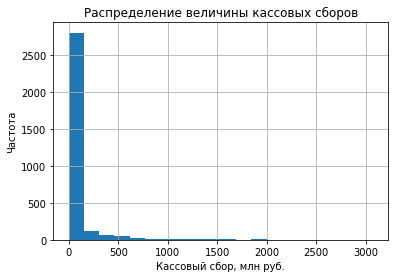

In [59]:
# Построим гистограмму распределения величины кассовых сборов
ax = data['box_office_mln'].hist(grid=True, bins=20)

ax.set_title('Распределение величины кассовых сборов')
ax.set_ylabel('Частота')
ax.set_xlabel('Кассовый сбор, млн руб.')
plt.show();

Большинство значений группируются около 0, значения по 750 млн встречаются очень редко

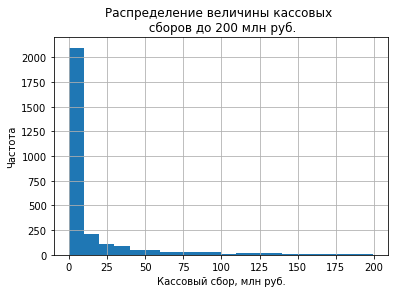

In [60]:
# Построим гистограмму по срезу со сбором до 200 млн
ax = data.query('box_office_mln <= 200')['box_office_mln'].hist(grid=True, bins=20)

ax.set_title('Распределение величины кассовых \n сборов до 200 млн руб.')
ax.set_ylabel('Частота')
ax.set_xlabel('Кассовый сбор, млн руб.')
plt.show();

Аналогичная картина - большинство значений группируются около нуля, значения свыше 100 млн руб встречаются редко

In [61]:
# Посмотрим на данные по срезу со сбором до 25 млн руб.
data.query('box_office_mln <= 25')

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office,support_budget,box_office_mln
6,Любовь и голуби,111007013,2013-10-18 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,В.Меньшов,unknown,«12+» - для детей старше 12 лет,0.00,0.00,0.00,Частное финансирование,8.30,"мелодрама,комедия",2700.00,0.00,0.00
18,Неподдающиеся,111003616,2016-02-12 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Ю.Чулюкин,unknown,«6+» - для детей старше 6 лет,0.00,0.00,0.00,Частное финансирование,8.00,"мелодрама,комедия",360.00,0.00,0.00
19,Неподсуден,111003716,2016-02-12 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,"В.Краснопольский, В.Усков",unknown,«6+» - для детей старше 6 лет,0.00,0.00,0.00,Частное финансирование,7.70,драма,420.00,0.00,0.00
22,"Операция ""Ы"" и другие приключения Шурика",111007413,2013-10-18 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Л.Гайдай,unknown,«6+» - для детей старше 6 лет,0.00,0.00,0.00,Частное финансирование,8.70,"комедия,мелодрама,криминал",380.00,0.00,0.00
38,Мужики!..,111007213,2013-10-18 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,И.Бабич,unknown,«6+» - для детей старше 6 лет,0.00,0.00,0.00,Частное финансирование,8.10,драма,1165.00,0.00,0.00
47,Андрей Рублев.,111029814,2014-12-24 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,А.Тарковский,unknown,«12+» - для детей старше 12 лет,0.00,0.00,0.00,Частное финансирование,8.20,"драма,биография,история",22660.00,0.00,0.02
50,Асса,111005815,2015-04-23 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,С.Соловьев,unknown,«16+» - для детей старше 16 лет,0.00,0.00,0.00,Частное финансирование,6.00,"фэнтези,боевик",84720.00,0.00,0.08
52,Айболит - 66,111010513,2013-12-19 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Ролан Быков,unknown,«0+» - для любой зрительской аудитории,0.00,0.00,0.00,Частное финансирование,7.10,"мюзикл,комедия,детский",1795.00,0.00,0.00
61,Американская дочь,111005515,2015-04-23 12:00:00+00:00,Художественный,"АО ""Караван"", Компания ""Америкен Дистрибьюшн"",...","Россия, Казахстан, США",К.Шахназаров,unknown,«6+» - для детей старше 6 лет,0.00,0.00,0.00,Частное финансирование,7.00,"драма,комедия",300.00,0.00,0.00
64,Аттестат зрелости,111005915,2015-04-23 12:00:00+00:00,Художественный,"Киностудия ""Мосфильм""",СССР,Т.Лукашевич,unknown,«12+» - для детей старше 12 лет,0.00,0.00,0.00,Частное финансирование,6.90,драма,67500.00,0.00,0.07


Получилось большое количество аномально низких сборов 200, 300 руб., 3000 руб. Проверим общее количество таких данных

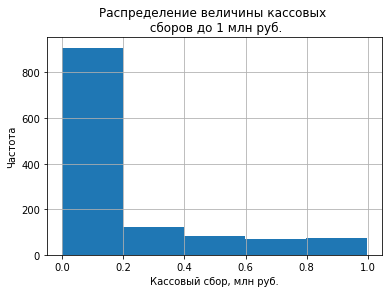

In [62]:
ax = data.query('box_office_mln <= 1')['box_office_mln'].hist(grid=True, bins=5)

ax.set_title('Распределение величины кассовых \n сборов до 1 млн руб.')
ax.set_ylabel('Частота')
ax.set_xlabel('Кассовый сбор, млн руб.')
plt.show();

Получилось более 800 случаев с кассовыми сборами до 200 тыс. руб. 

Предположить по каким конкретно случаям могут быть проблемы с ошибкой в размерности данных проблематично, так как таких данных очень много, исправить их точечно затруднительно, так как порядок ошибки может быть везде разный (где то в тысячу раз, где то в миллион). Оставим пока данные без изменения, ситуация прояснится в разделе исследовательского анализа данных.

In [63]:
# Проверим изменение размеров датасета
print(data.shape[0]-temp.shape[0],
      round(
          (data.shape[0]-temp.shape[0])/temp.shape[0]*100,2)
      )

-19 -0.25


In [64]:
# Комментарий ревьюера
# Проверим сколько удалено строк датасета
a, b = len(temp), len(data)
print(a, b, round((a-b)/a*100, 2))

7486 7467 0.25


#### Шаг 2.6. Добавьте новые столбцы





- Создайте столбец с информацией о годе проката. Выделите год из даты премьеры фильма.

In [65]:
# Создадим столбец с годом выхода фильма в прокат
data['year'] = data['show_start_date'].dt.year

- Создайте два столбца: с именем и фамилией главного режиссёра и основным жанром фильма. В столбцы войдут первые значения из списка режиссёров и жанров соответственно.

<div id="accordion">
    <div class="card">
        <div class="card-header" id="headingThree">
            <button class="btn btn-link collapsed" data-toggle="collapse" data-target="#collapseHint_2" aria-expanded="false" aria-controls="collapseHint_2">Подсказка</button>
        </div>
        <div id="collapseHint_2" class="collapse" aria-labelledby="headingThree" data-parent="#accordion">
            <div class="card-body">
Чтобы создать такие столбцы, лучше всего использовать собственную функцию. Эту функцию можно применить к двум столбцам сразу. 
            </div>
        </div>
    </div>
</div>

In [66]:
# Создадим столбец с именем главного режиссера
data['main_director'] = data['director'].apply(lambda x: x.split(',')[0].strip())

In [67]:
# Создадим столбец с названием главного жанра
data['main_genre'] = data['genres'].apply(lambda x: x.split(',')[0].strip())

In [68]:
# Комментарий ревьюера
df = data.copy()
df[['director', 'main_director', 'genres', 'main_genre']][150:151]

,director,main_director,genres,main_genre
150,"А.Столпер, Б.Иванов",А.Столпер,unknown,unknown


In [69]:
# Проверим созданные столбцы
data.sample(10)

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office,support_budget,box_office_mln,year,main_director,main_genre
3672,Сборник романтических комедий - 2,126000717,2017-06-05 12:00:00+00:00,Прочие,"Китчен Корпорейшн, Лагенс де Курт Метраж, Магн...",Испания - Франция - США - Великобритания - Бел...,"С.Абрахамс, Ф.Гарсиа-Руис, Р.Лиментани, Т.Рози...","С.Абрахамс, М.И.Апштейн, А.О.Арангурен, Ф.Бро...",«18+» - запрещено для детей,0.00,0.00,0.00,Частное финансирование,NaN,unknown,1915621.00,0.00,1.92,2017,С.Абрахамс,unknown
3570,Секретный агент (2017),121007417,2017-04-25 12:00:00+00:00,Художественный,"Блум, Чех Англо Продакшнз, Ди Бонавентура Пикч...",Великобритания,Майкл Аптед,"Лоренцо Ди Бонавентура, Джорджина Таунси, Эри...",«18+» - запрещено для детей,0.00,0.00,0.00,Частное финансирование,5.90,"боевик,триллер",24941936.00,0.00,24.94,2017,Майкл Аптед,боевик
5344,Бедная богатая девочка,121023511,2011-12-15 12:00:00+00:00,Художественный,"Парамаунт Пикчерз, Дэнвер энд Делайла Продакшн...",США,Джейсон Ритмэн,"Диабло Коуди, Мэйсон Новик, Джейсон Ритмэн, Ра...",«16+» - для детей старше 16 лет,0.00,0.00,0.00,Частное финансирование,6.00,"драма,комедия",NaN,0.00,NaN,2011,Джейсон Ритмэн,драма
2047,Феи: Легенда о чудовище,124003314,2014-12-17 12:00:00+00:00,Анимационный,"Дисней Тун Студиос, Прана Студиос",США,Стив Лотер,Макул Вигерт,«0+» - для любой зрительской аудитории,0.00,0.00,0.00,Частное финансирование,7.50,"мультфильм,фэнтези,приключения",16429913.00,0.00,16.43,2014,Стив Лотер,мультфильм
5884,Вымогательство,121010218,2018-05-30 12:00:00+00:00,Художественный,"Дель Рей Продакшнз, Филммюз Продакшнз, Продюсе...",США - Пуэрто Рико,Филипп Волкен,"Филипп Волкен, Алина Шрайбман",«18+» - запрещено для детей,0.00,0.00,0.00,Частное финансирование,6.30,"боевик,триллер,драма",NaN,0.00,NaN,2018,Филипп Волкен,боевик
6143,ОТ СЛАВНОГО ПРОШЛОГО К УСПЕШНОМУ БУДУЩЕМУ,112006118,2018-08-06 12:00:00+00:00,Документальный,"РОО ""Ассоциация ""Наше кино""",Россия,В.Кильчевская,А.Эмир-Шах,«12+» - для детей старше 12 лет,0.00,0.00,0.00,Частное финансирование,7.00,драма,NaN,0.00,NaN,2018,В.Кильчевская,драма
5237,Вольфганг Амадей Моцарт. Свадьба Фигаро /По од...,126002911,2011-12-05 12:00:00+00:00,Прочие,Синема Лайв,Австралия,Нил Армфилд,unknown,«0+» - для любой зрительской аудитории,0.00,0.00,0.00,Частное финансирование,NaN,unknown,NaN,0.00,NaN,2011,Нил Армфилд,unknown
4324,Бандиты,221026910,2010-01-29 12:00:00+00:00,Художественный,Метро Голдвин Майер в сотрудничестве с Хайд Па...,США,Барри Левинсон,"Паула Вейнстейн, Барри Левинсон",«16+» - для детей старше 16 лет,0.00,0.00,0.00,Частное финансирование,6.10,"короткометражка,боевик,драма",NaN,0.00,NaN,2010,Барри Левинсон,короткометражка
3187,В центре внимания,121003116,2016-02-11 12:00:00+00:00,Художественный,"Анонимус Контент, Фёст Лук Медиа, Партисипэнт ...",США,Том МакКарти,"Стив Голин, Николь Роклин, Блай Пэгон Фауст",«18+» - запрещено для детей,0.00,0.00,0.00,Частное финансирование,7.50,"драма,криминал,биография",10251855.50,0.00,10.25,2016,Том МакКарти,драма
5024,Огни притона,111006811,2011-10-20 12:00:00+00:00,Художественный,"ООО ""Ин Моушн""",Россия,А.Гордон,Е.Яцура,«16+» - для детей старше 16 лет,0.00,0.00,0.00,Частное финансирование,6.70,драма,NaN,0.00,NaN,2011,А.Гордон,драма


Поля с годом, именем главного режиссера и жанром добавлены

- Посчитайте, какую долю от общего бюджета фильма составляет государственная поддержка.

In [70]:
# Функция для расчета доли государственной поддержки
def gov_support_ratio(row):
    budget = row['budget']
    support = row['support_budget']
    if budget == 0:
        return 0
    else:
        return support / budget

In [71]:
# Добавим столбец с долей государственной поддержки в общем бюджете фильма
data['gov_support_ratio'] = data.apply(gov_support_ratio, axis=1)

**Выводы по предобработке данных:**

* Заполнены пропуски по категориальным полям ("заглушками"), по фильмам без господдержки данные по поддержке и бюджету заполнены нулями. По полям рейтинга и кассовых сборов пропуски не заполнялись

* По полю кассовых сборов есть большое количество аномальных данных, вероятно проблемы с размерностью, их природа и закономерность неясна. Изменения по данному полю не производились.

* Удалены неявные дубликаты по номеру прокатного удостоверения, явных (полных) дублей не обнаружено.

* По результатам предобработки датасет сократился на 0.25%


### Шаг 3. Проведите исследовательский анализ данных


- Посмотрите, сколько фильмов выходило в прокат каждый год. Обратите внимание, что данные о прокате в кинотеатрах известны не для всех фильмов. Посчитайте, какую долю составляют фильмы с указанной информацией о прокате в кинотеатрах. Проанализируйте, как эта доля менялась по годам. Сделайте вывод о том, какой период полнее всего представлен в данных.

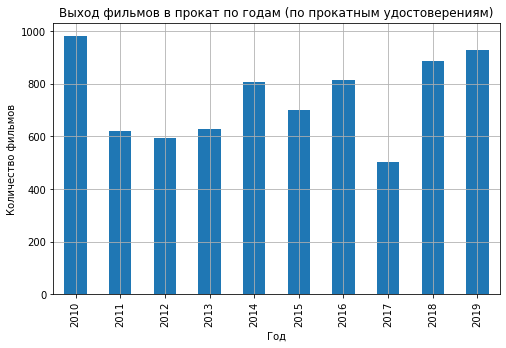

In [72]:
# Выход фильмов в прокат по годам - посчитаем кол-во прокатных удостоверений по их номерам (где указано)
ax = (
data.query('puNumber != "нет"').groupby('year')['year'].agg('count')
.plot(kind='bar',
      legend=False,
      figsize=(8,5),
      grid = True,
      title='Выход фильмов в прокат по годам (по прокатным удостоверениям)')
)
ax.set_ylabel('Количество фильмов')
ax.set_xlabel('Год');

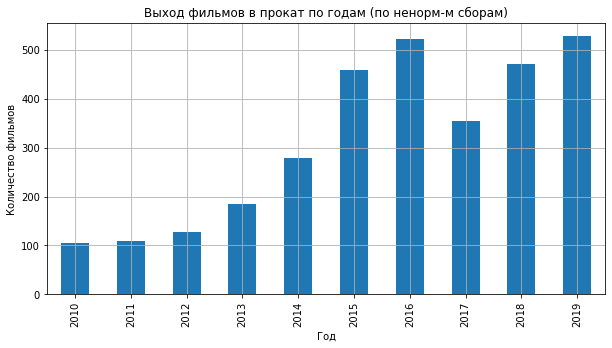

In [73]:
# Аналогично построим график по количеству выхода фильмов где известны сборы в прокате

ax = (data.query('~box_office.isna()').groupby('year')['year'].agg('count')
.plot(kind='bar',
      legend=False,
      figsize=(10,5),
      grid = True,
      title='Выход фильмов в прокат по годам (по ненорм-м сборам)')
)
ax.set_ylabel('Количество фильмов')
ax.set_xlabel('Год');

График динамики количества фильмов рассчитанный по количеству прокатных удостоверений и по наличию информации о прокате существенно отличаются за период 2010-2014 гг. Данных по фильмам с информацией о прокате в 2010-2014 гг. существенно меньше, чем в последующие периоды.

In [74]:
# Доля фильмов с указанной информацией о прокате
data.query('~box_office.isna()').shape[0] / data.query('puNumber != "нет"').shape[0] * 100

42.070720600053576

Информация о прокате есть у 42% фильмов.

In [75]:
# Посчитаем изменение доли фильмов с имеющейся информацией о прокате
box = data.pivot_table(index='year', values=['puNumber','box_office'], aggfunc='count')
box['ratio'] = box['box_office'] / box['puNumber'] * 100
box

,box_office,puNumber,ratio
year,,,
2010,105,983,10.68
2011,109,622,17.52
2012,128,593,21.59
2013,184,630,29.21
2014,278,806,34.49
2015,459,699,65.67
2016,523,815,64.17
2017,355,503,70.58
2018,471,887,53.10


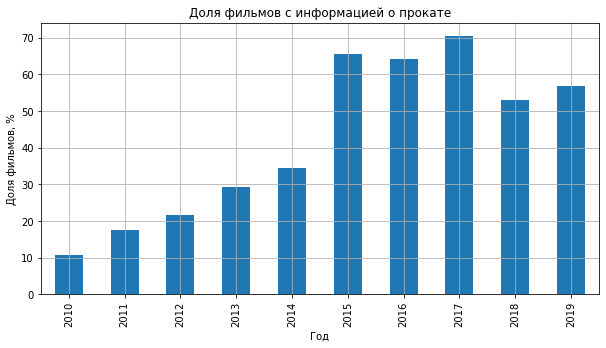

In [76]:
# Построим график для полученных данных

ax = (box.plot(kind='bar',
      y = 'ratio',
      legend=False,
      figsize=(10,5),
      grid = True,
      title='Доля фильмов с информацией о прокате'
        )
)
ax.set_ylabel('Доля фильмов, %')
ax.set_xlabel('Год');

Динамика по обоим вариантам расчета в целом похожа на динамику выхода фильмов в прокат. Наименьшая доля фильмов с информацией о прокате в 2010-2014 годах. Таким образом наиболее полная информация о прокате фильмов представлена за 2015 и последующие года

- Изучите, как менялась динамика проката по годам. В каком году сумма сборов была минимальной? А максимальной?

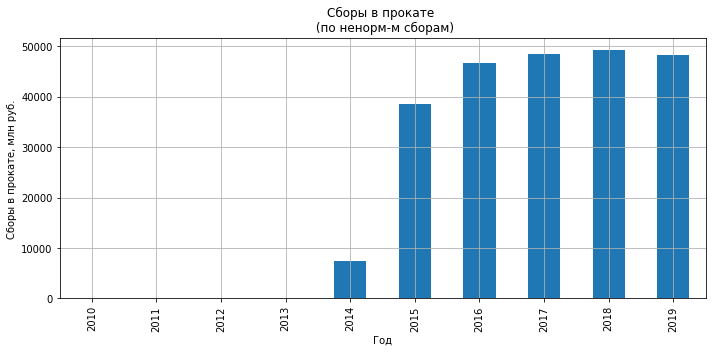

In [77]:
# Посчитаем динамику сборов от проката по годам в миллионах рублей по исходным данным
ax = (data.pivot_table(index='year', values=['box_office_mln'], aggfunc='sum').plot(
      kind='bar',
      y = 'box_office_mln',
      legend=False,
      figsize=(10,5),
      grid = True,
      title='Сборы в прокате \n (по ненорм-м сборам)')
     )

ax.set_ylabel('Сборы в прокате, млн руб.')
ax.set_xlabel('Год')

plt.tight_layout();

По графику складывается впечатление, что за 2010-2013 гг полностью отсутствуют данные о сборах в прокате. Посмотрим отдельно на данные в сводной таблице

In [78]:
# Сводная таблица по сборам в прокате по годам
data.pivot_table(index='year', values=['box_office_mln'], aggfunc='sum')

,box_office_mln
year,
2010,2.43
2011,14.10
2012,6.96
2013,29.80
2014,7434.72
2015,38527.83
2016,46742.32
2017,48458.15
2018,49251.99


Действительно, получились аномально низкие значения величины сборов в 2010-2014 гг. Как ранее отмечалось, неочевидна закономерность появления таких малых величин, особенно если смотреть выборочно по отдельным фильмам за этот период. Для дальнейшего анализа было бы логично отбросить данные за 2010-2014 гг.

In [79]:
# Посчитаем какую долю составляют данные за 2010-2014 гг от текущего датасета
data.query('year<2015').shape[0]/data.shape[0]*100

48.667470202223114

Таких данных получилось почти 49%, очень большая величина, но анализировать некорректные или искаженные данные также не имеет смысла.

- С помощью сводной таблицы посчитайте среднюю и медианную сумму сборов для каждого года.

In [80]:
# Средняя и медианная сумма сборов
data.pivot_table(index='year', values='box_office', aggfunc=['mean','median', 'min', 'max', 'std'])

,mean,median,min,max,std
,box_office,box_office,box_office,box_office,box_office
year,,,,,
2010,23130.04,1700.00,0.00,1446400.00,143375.39
2011,129383.17,3000.00,125.00,11618085.00,1114446.84
2012,54339.24,5660.00,0.00,2311220.00,229284.79
2013,161954.92,3522.50,0.00,19957031.50,1504848.61
2014,26743589.36,18137.50,0.00,1016410635.30,121276644.96
2015,83938621.35,4784781.50,0.00,1658861425.50,220807728.05
2016,89373453.67,3776087.56,0.00,2048126108.00,248297842.23
2017,136501823.25,9919415.00,7900.00,2779686144.00,324102502.18


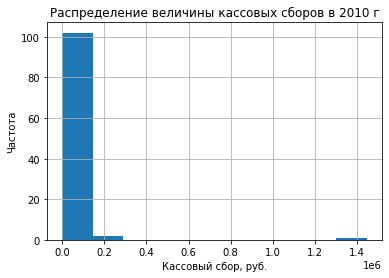

In [81]:
# Гистограмма распределения кассовых сборов для 2010 г.
ax = data.query('year==2010')['box_office'].hist(grid=True, bins=10)
ax.set_title('Распределение величины кассовых сборов в 2010 г')
ax.set_ylabel('Частота')
ax.set_xlabel('Кассовый сбор, руб.');

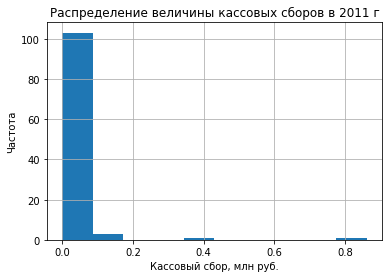

In [82]:
# Гистограмма распределения кассовых сборов для 2011 г.
ax = data.query('year==2011 and box_office_mln<1')['box_office_mln'].hist(grid=True, bins=10)
ax.set_title('Распределение величины кассовых сборов в 2011 г')
ax.set_ylabel('Частота')
ax.set_xlabel('Кассовый сбор, млн руб.');

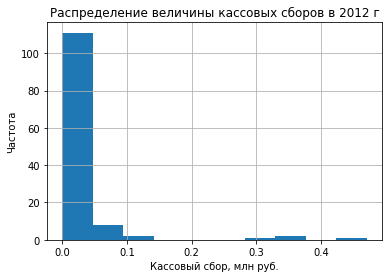

In [83]:
# Гистограмма распределения кассовых сборов для 2012 г.
ax = data.query('year==2012 and box_office_mln<0.5')['box_office_mln'].hist(grid=True, bins=10)
ax.set_title('Распределение величины кассовых сборов в 2012 г')
ax.set_ylabel('Частота')
ax.set_xlabel('Кассовый сбор, млн руб.');

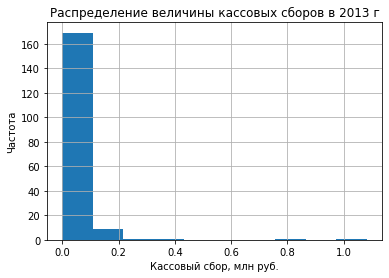

In [84]:
# Гистограмма распределения кассовых сборов для 2013 г.
ax = data.query('year==2013 and box_office_mln<2')['box_office_mln'].hist(grid=True, bins=10)
ax.set_title('Распределение величины кассовых сборов в 2013 г')
ax.set_ylabel('Частота')
ax.set_xlabel('Кассовый сбор, млн руб.');

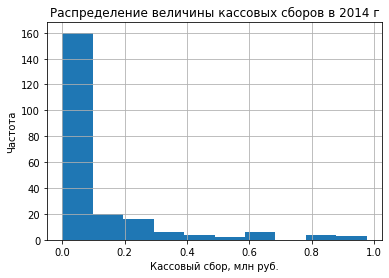

In [85]:
# Гистограмма распределения кассовых сборов для 2014 г.
ax = data.query('year==2014 and box_office_mln<1')['box_office_mln'].hist(grid=True, bins=10)
ax.set_title('Распределение величины кассовых сборов в 2014 г')
ax.set_ylabel('Частота')
ax.set_xlabel('Кассовый сбор, млн руб.');

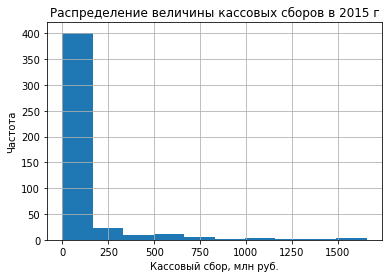

In [86]:
# Гистограмма распределения кассовых сборов для 2015 г.
ax = data.query('year==2015')['box_office_mln'].hist(grid=True, bins=10)
ax.set_title('Распределение величины кассовых сборов в 2015 г')
ax.set_ylabel('Частота')
ax.set_xlabel('Кассовый сбор, млн руб.');

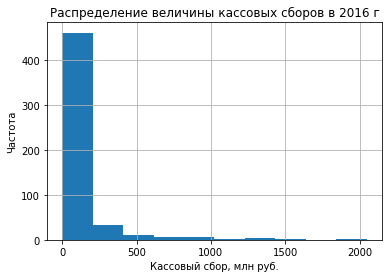

In [87]:
# Гистограмма распределения кассовых сборов для 2016 г.
ax = data.query('year==2016')['box_office_mln'].hist(grid=True, bins=10)
ax.set_title('Распределение величины кассовых сборов в 2016 г')
ax.set_ylabel('Частота')
ax.set_xlabel('Кассовый сбор, млн руб.');

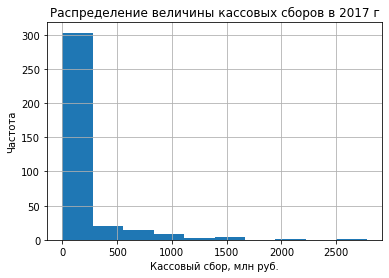

In [88]:
# Гистограмма распределения кассовых сборов для 2017 г.
ax = data.query('year==2017')['box_office_mln'].hist(grid=True, bins=10)
ax.set_title('Распределение величины кассовых сборов в 2017 г')
ax.set_ylabel('Частота')
ax.set_xlabel('Кассовый сбор, млн руб.');

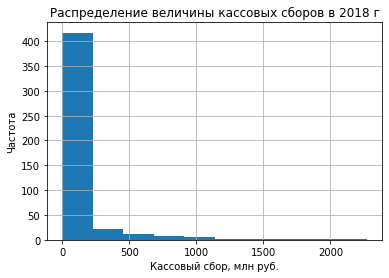

In [89]:
# Гистограмма распределения кассовых сборов для 2018 г.
ax = data.query('year==2018')['box_office_mln'].hist(grid=True, bins=10)
ax.set_title('Распределение величины кассовых сборов в 2018 г')
ax.set_ylabel('Частота')
ax.set_xlabel('Кассовый сбор, млн руб.');

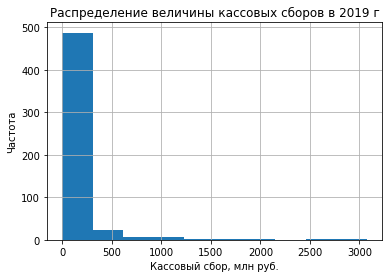

In [90]:
# Гистограмма распределения кассовых сборов для 2019 г.
ax = data.query('year==2019')['box_office_mln'].hist(grid=True, bins=10)
ax.set_title('Распределение величины кассовых сборов в 2019 г')
ax.set_ylabel('Частота')
ax.set_xlabel('Кассовый сбор, млн руб.');

**2010**
* Средний сбор - 23 тыс.руб., медианный - 1.7 тыс. руб.
* Подавляющая доля значений сконцентрирована в диапозоне 0-300 тыс. руб., есть очень малая доля в диапозоне 1.2-1.4 млн руб. Это объяснет большую разницу между средней и медианной, срединное значение по выборке тяготеет к 1.7 тыс руб., в то время как среднеарифмитеческое получается выше за счет наличия экстремально высоких значений. 


**2011**
* Средний сбор - 129 тыс.руб., медианный - 3 тыс. руб. Ситуация аналогичная с 2010 г.
* Подавляющее количество значений находится в диапозоне до 100 тыс. руб.

**2012**
* Средний сбор - 54 тыс.руб., медианный - 5.6 тыс. руб.
* Подавляющее количество значений находится в диапозоне до 50 тыс. руб.
* Разница также объясняется влиянием на среднее наличием единичных экстремально высоких значений при основной массе значений до 50 тыс. руб.

**2013**
* Средний сбор - 162 тыс.руб., медианный - 3.5 тыс. руб.
* Подавляющее количество значений находится в диапозоне до 100 тыс. руб.
* Разница средней и медианы объясняется влиянием на среднее наличием единичных экстремально высоких значений при основной массе значений до 100 тыс. руб.

**2014**
* Средний сбор - 26.7 млн руб., медианный - 18 тыс. руб.
* Подавляющее количество значений находится в диапозоне до 100 тыс. руб.

**2015**
* Средний сбор - 84 млн руб., медианный - 4.8 млн руб.
* Подавляющее количество значений находится в диапозоне до 200 млн руб. с высокой концентрацией значений в диапозоне 0-5 млн руб.

**2016**
* Средний сбор - 89 млн руб., медианный - 3.8 млн руб.	
* Подавляющее количество значений находится в диапозоне до 250 млн руб. с высокой концентрацией значений в диапозоне 0-5 млн руб.

**2017**
* Средний сбор - 136.5 млн руб., медианный - 10 млн руб.	 
* Подавляющее количество значений находится в диапозоне до 500 млн руб. с высокой концентрацией значений в диапозоне 0-10 млн руб.

**2018**
* Средний сбор - 104.6 млн руб., медианный - 8.8 млн руб.
* Подавляющее количество значений находится в диапозоне до 500 млн руб. с высокой концентрацией значений в диапозоне 0-25 млн руб.

**2019**
* Средний сбор - 91 млн руб., медианный - 4.6 млн руб.
* Подавляющее количество значений находится в диапозоне до 500 млн руб. с высокой концентрацией значений в диапозоне 0-20 млн руб.

**Резюме**
* Во всех годах присутствует существенная разница между средним и медианным значением кассовых сборов в российских кинотеатрах. Везде среднее значительно выше медианы. Это объясняется тем, что на медиану оказывает большое количество малых значений величины сборов, в то время как среднеарифмитечская зависит от всех значений в выборке и искажается экстремально высокими значениями в большую сторону.
* Проведенный анализ еще раз показал аномальный характер данных по сборам за 2010-2014 гг, что вероятно связано с ошибками в размерности величин


In [91]:
# Для удобства добавим колонку с коротким вариантом написания возрастного ограничения
data['age_restr_shrt'] = data['age_restriction'].apply(lambda x: x.split('-')[0].strip())

Сделаем срез для фильмов с 2015 г. и посчитаем их суумарный сбор в разрезе возрастных ограничений. Будем использовать исходные данные по сборам, так как за рассматриваемый период исходные данные идентичны скорректированным

In [92]:
data.query('year>2014').groupby('age_restr_shrt')['box_office_mln'].agg('sum')

age_restr_shrt
«0+»      809.08
«12+»   59369.19
«16+»   75102.27
«18+»   40757.66
«6+»    55220.19
Name: box_office_mln, dtype: float64

За 2015-2019 гг наибольшую кассу принесли фильмы в возрастной категории 16+ - 75 млрд рублей. В целом фильмы для детей и подростков принесли за указанный период 191 млрд рублей, в то время как фильмы для взрослых всего ~41 млрд. руб.

In [93]:
# Проверим динамику кассовых сборов по годам в разрезе категорий возрастных ограничений
(
data.query('year>2014')
 .pivot_table(index='age_restr_shrt',
              columns='year',
              values='box_office_mln',
              aggfunc='sum')
)

year,2015,2016,2017,2018,2019
age_restr_shrt,,,,,
«0+»,379.05,150.23,229.60,32.45,17.75
«12+»,13419.51,11150.76,7851.43,14267.29,12680.20
«16+»,10781.60,16594.25,18694.59,16278.41,12753.42
«18+»,5430.35,6793.93,9651.50,8760.09,10121.80
«6+»,8517.31,12053.15,12031.03,9913.76,12704.94


In [94]:
# Проверим количество премьер по годам в разрезе категорий возрастных ограничений
(
data.query('year>2014')
 .pivot_table(index='age_restr_shrt',
              columns='year',
              values='puNumber',
              aggfunc='count')
)

year,2015,2016,2017,2018,2019
age_restr_shrt,,,,,
«0+»,50,73,44,77,73
«12+»,136,134,70,243,203
«16+»,246,268,152,234,266
«18+»,191,245,172,222,255
«6+»,76,95,65,111,132


* В 2018-2019 гг существенно сократились сборы фильмов в категории 0+, при этом количество премьер осталось примерно на одном уровне
* Сборы фильмов в категориях 12+, 16+, 6+ колеблются примерно на одном уровне
* Сборы фильмов 18+ медленно растут

Для наглядности добавим новую обобщенную категорию возрастных ограничений - "Дети и подростки", "Взрослые"

In [95]:
data['age_group'] = data['age_restr_shrt'].apply(lambda x: 'Взрослые' if x=='«18+»' else 'Дети и подростки')

In [96]:
(
data.query('year>2014')
 .pivot_table(index='age_group',
              columns='year',
              values='puNumber',
              aggfunc='count')
)

year,2015,2016,2017,2018,2019
age_group,,,,,
Взрослые,191,245,172,222,255
Дети и подростки,508,570,331,665,674


In [97]:
(
data.query('year>2014')
 .pivot_table(index='age_group',
              columns='year',
              values='box_office_mln',
              aggfunc='sum')
)

year,2015,2016,2017,2018,2019
age_group,,,,,
Взрослые,5430.35,6793.93,9651.50,8760.09,10121.80
Дети и подростки,33097.48,39948.39,38806.65,40491.91,38156.31


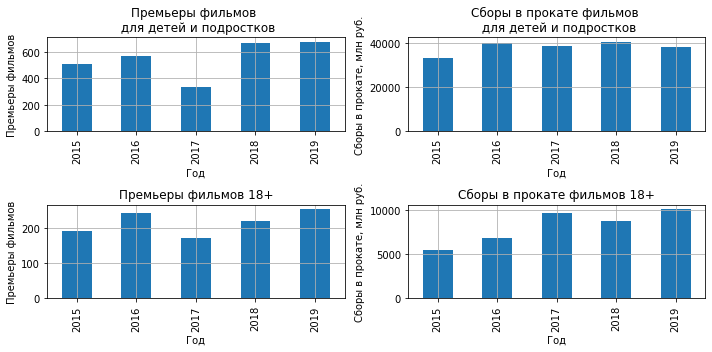

In [98]:
# Построим графики для фильмов 18-
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 15))

ax = (data.query('year>2014 and age_group =="Дети и подростки"')
 .groupby('year')['puNumber'].agg('count')
 .plot(
        kind='bar',
        y = 'puNumber',
        legend=False,
        figsize=(10,5),
        grid = True,
        title='Премьеры фильмов \n для детей и подростков',
        ax=axes[0,0])
     )

ax.set_ylabel('Премьеры фильмов')
ax.set_xlabel('Год')

ax = (data.query('year>2014 and age_group =="Дети и подростки"')
 .groupby('year')['box_office_mln'].agg('sum')
 .plot(
      kind='bar',
      y = 'box_office_mln',
      legend=False,
      figsize=(10,5),
      grid = True,
      title='Сборы в прокате фильмов \n для детей и подростков',
      ax=axes[0,1])
     )

ax.set_ylabel('Сборы в прокате, млн руб.')
ax.set_xlabel('Год')

# Графики для фильмов 18+
ax = (data.query('year>2014 and age_group =="Взрослые"')
 .groupby('year')['puNumber'].agg('count')
 .plot(
        kind='bar',
        y = 'puNumber',
        legend=False,
        figsize=(10,5),
        grid = True,
        title='Премьеры фильмов 18+',
        ax=axes[1,0])
     )

ax.set_ylabel('Премьеры фильмов')
ax.set_xlabel('Год')

ax = (data.query('year>2014 and age_group =="Взрослые"')
 .groupby('year')['box_office_mln'].agg('sum')
 .plot(
      kind='bar',
      y = 'box_office_mln',
      legend=False,
      figsize=(10,5),
      grid = True,
      title='Сборы в прокате фильмов 18+',
      ax=axes[1,1])
     )

ax.set_ylabel('Сборы в прокате, млн руб.')
ax.set_xlabel('Год')

plt.tight_layout();

plt.show()

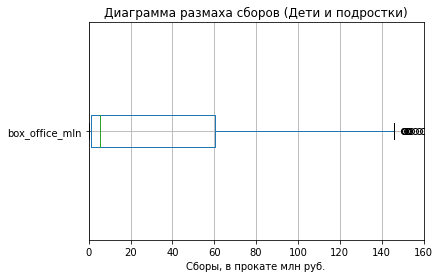

In [99]:
# Построим диаграммы размаха сборов

# Дети и подростки
plt.xlim(0,160)
ax = (data.query('year>2014 and age_group =="Дети и подростки"').boxplot('box_office_mln',
                                                                  vert=False,
                                                                  grid=True)
     )
ax.set_title('Диаграмма размаха сборов (Дети и подростки)')                                                                        
ax.set_xlabel('Сборы, в прокате млн руб.');

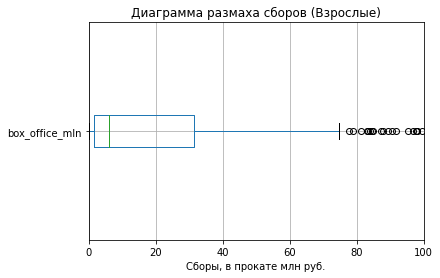

In [100]:
# Взрослые
plt.xlim(0,100)
ax = (data.query('year>2014 and age_group =="Взрослые"').boxplot('box_office_mln',
                                                                  vert=False,
                                                                  grid=True)
     )
ax.set_title('Диаграмма размаха сборов (Взрослые)')                                                                        
ax.set_xlabel('Сборы, в прокате млн руб.');

**Дети и подростки**
* Почти все сборы попадают в диапозон 0 - 150 млн руб., сборы свыше 150 млн руб. определяются как выбросы.
* Межквартильный размах соответствует диапозону 0-60 млн руб.
* Медиана сборов - около 5 млн руб.


**Взрослые**
* Почти все сборы попадают в диапозон 0 - 75 млн руб., сборы свыше 75 млн руб. определяются как выбросы.
* Межквартильный размах соответствует диапозону 0-30 млн руб.
* Медиана сборов - около 5 млн руб.

* Динамика количества премьер по обеим категориям схожа, с разницей в абсолютном количестве премьер (фильмов для детей и подростков снимается больше примерно в 2-3 раза
* В 2017 году по обеим категориям фильмов фиксируется заметное снижение количества премьер фильмов
* Кассовые сборы фильмов для детей и подростков стабильно находятся на отметке около 40 млрд руб ежегодно, без какой либо явной тенденции к росту или снижению.
* На графике кассовых сборов фильмов 18+ заметен тренд к увеличению суммы сборов, так начиная с 2015 года сборы выросли с ~5 млрд до 10 млрд руб. в 2019 г.
* На полученных диаграмах размаха для категорий фильмов 18+ и 18- получились схожие виличины медианного кассового сбора. При этом размах сборов для фильмов 18- в два раза выше чем для фильмов 18+

**Вывод по исследовательскому анализу данных**

* Динамика количества фильмов рассчитанная по количеству прокатных удостоверений и по наличию информации о прокате существенно отличаются за период 2010-2014 гг. Данных по фильмам с информацией о прокате в 2010-2014 гг. существенно меньше, чем в последующие периоды.


* В 2010-2014 гг аномально низкие значения величины сборов. Неочевидна закономерность появления таких малых величин, особенно если смотреть выборочно по отдельным фильмам за этот период. Для дальнейшего анализа где участвует величина кассовых сборов логичней было бы отбрасывать данные за 2010-2014 гг. Объем таких данных составляет 49% от всего датасета.


* Во всех годах присутствует существенная разница между средним и медианным значением кассовых сборов в российских кинотеатрах. Везде среднее значительно выше медианы. Это объясняется тем, что на медиану оказывает большое количество малых значений величины сборов, в то время как среднеарифмитечская зависит от всех значений в выборке и искажается экстремально высокими значениями в большую сторону.
* Проведенный анализ еще раз показал аномальный характер данных по сборам за 2010-2014 гг, что вероятно связано с ошибками в размерности величин.


* В 2018-2019 гг существенно сократились сборы фильмов в категории 0+, при этом количество премьер осталось примерно на одном уровне
* Сборы фильмов в категориях 12+, 16+, 6+ колеблются примерно на одном уровне
* Сборы фильмов 18+ медленно растут


* Динамика количества премьер по обеим категориям ("Взрослые" и "Дети и подростки") схожа, с разницей в абсолютном количестве премьер (фильмов для детей и подростков снимается больше примерно в 2-3 раза.
* В 2017 году по обеим категориям фильмов фиксируется заметное снижение количества премьер фильмов.
* Кассовые сборы фильмов для детей и подростков стабильно находятся на отметке около 40 млрд руб ежегодно, без какой либо явной тенденции к росту или снижению.
* На графике кассовых сборов фильмов 18+ заметен тренд к увеличению суммы сборов, так начиная с 2015 года сборы выросли с ~5 млрд до 10 млрд руб. в 2019 г.
* На полученных диаграмах размаха для категорий фильмов 18+ и 18- получились схожие виличины медианного кассового сбора. При этом размах сборов для фильмов 18- в два раза выше чем для фильмов 18+

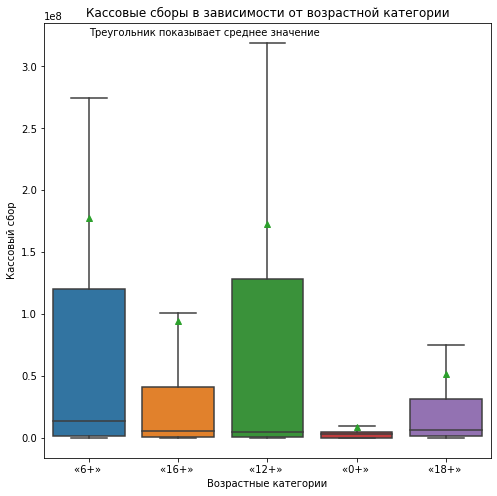

In [101]:
# Комментарий ревьюера 2
import seaborn as sns
temp = data[data.box_office > 0].copy()
# для удобства укоротим названия категорий
def get_first_value(s, sep = ','):  # Функция для выбора первого элемента из перечисления
    value_lst = s.split(sep=sep)
    return value_lst[0]

temp['age_restriction'] = temp['age_restriction'].apply(lambda x: get_first_value(x, sep='-'))
# сохраним маску для среза по годам
year_mask = temp['year'] >= 2015

plt.figure(figsize=(8, 8))
(sns.boxplot(data = temp.loc[year_mask], y = 'box_office', x='age_restriction', showfliers=False, showmeans=True)
    .set(title = 'Кассовые сборы в зависимости от возрастной категории', 
         xlabel = 'Возрастные категории', ylabel = 'Кассовый сбор'))
plt.text(0, 3.25e8,'Треугольник показывает среднее значение')
plt.show()

### Шаг 4. Исследуйте фильмы, которые получили государственную поддержку

На этом этапе нет конкретных инструкций и заданий — поищите интересные закономерности в данных. Посмотрите, сколько выделяют средств на поддержку кино. Проверьте, хорошо ли окупаются такие фильмы, какой у них рейтинг.

In [102]:
# Сделаем срез фильмов с господдержкой для дальнейшего анализа.
supported_films = data.query('budget !=0').copy()

In [103]:
# Посчитаем количество фильмов с господдержкой в выборке
supported_films.shape[0]

315

#### Выделение средств на поддержку кино

In [104]:
# Найдем сумму господдержки
supported_films['support_budget'].sum() / 1000000

18808.718847

Получилось 18.8 млрд рублей

In [105]:
# Для удобства переведем поля с бюджетом и размером поддержки в миллионах
supported_films['support_budget'] = supported_films['support_budget'] / 1000000
supported_films['budget'] = supported_films['budget'] / 1000000
supported_films['refundable_support'] = supported_films['refundable_support'] / 1000000
supported_films['nonrefundable_support'] = supported_films['nonrefundable_support'] / 1000000

In [106]:
# Найдем долю невозвратной поддержки в общем объеме выделяемой поддержки
supported_films['nonrefundable_support'].sum()/supported_films['support_budget'].sum()

0.8056752280826945

81% из 18.8 млрд - невозвратная поддержка фильмов

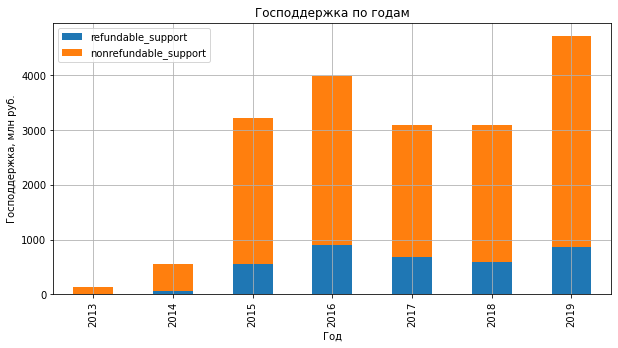

In [107]:
# Построим график выделения господдержки по годам

ax = (
supported_films.groupby('year')['refundable_support','nonrefundable_support'].agg('sum')
.plot(
        kind='bar',
        y = ['refundable_support','nonrefundable_support'],
        legend=True,
        figsize=(10,5),
        grid = True,
        title='Господдержка по годам',
        stacked=True
     )
)
ax.set_ylabel('Господдержка, млн руб.')
ax.set_xlabel('Год');

Данные по господдержке фильмов имеются начиная с 2013 г., резкий рост поддержки произошел в 2015 г. В 2015-2019 гг объем господдержки варьируется в диапозоне 3 - 5 млрд руб / год без какого-то явного тренда, приэтом видно, что подавляющая часть господдержки - невозвратная.

In [108]:
# Посчитаем как меняется доля господдержки в бюджете фильма по годам
sf_pivot = supported_films.pivot_table(index='year', values=['budget','support_budget'], aggfunc='sum')
sf_pivot['support_ratio'] = sf_pivot['support_budget'] / sf_pivot['budget']

In [109]:
sf_pivot

,budget,support_budget,support_ratio
year,,,
2013,255.44,134.35,0.53
2014,1279.48,549.00,0.43
2015,7309.67,3227.24,0.44
2016,7228.94,3977.16,0.55
2017,6972.17,3098.97,0.44
2018,6651.69,3098.00,0.47
2019,12542.87,4724.00,0.38


Доля господдержки варьируется в диапозоне 38-55% от бюджетов фильмов, наименьшая доля зафиксирована в 2019 году (38%)

In [110]:
# Топ-10 режиссеров по поддержке
directors_support_pivot = supported_films.pivot_table(index='main_director',
                                                      values=['budget','support_budget'],
                                                      aggfunc='sum')
directors_support_pivot['support_ratio'] = directors_support_pivot['support_budget'] / directors_support_pivot['budget']

In [111]:
directors_support_pivot.query('main_director !="unknown"').sort_values(by='support_budget',
                                                                     ascending=False).head(10)

,budget,support_budget,support_ratio
main_director,,,
Н.Хомерики,883.70,600.00,0.68
Ф.Бондарчук,944.00,500.00,0.53
А.Кравчук,980.00,500.00,0.51
Р.Давлетьяров,770.43,459.85,0.60
А.Мизгирев,684.20,450.00,0.66
Н.Лебедев,635.28,442.10,0.70
А.Мегердичев,590.19,400.00,0.68
Д.Дьяченко,780.70,351.00,0.45
Д.Киселев,702.82,350.00,0.50


Федор Бондарчук на 2-м месте с 750 млн руб. господдержки, доля государства в бюджете его фильмов - 53%. Остальные режиссеры мне не известны, посмотрим какие фильмы снимал Н.Хомерики

In [112]:
# Фильмы режиссера Н.Хомерики с участием господдержки
data.query('main_director=="Н.Хомерики" and budget!=0')

,title,puNumber,show_start_date,type,film_studio,production_country,director,producer,age_restriction,refundable_support,nonrefundable_support,budget,financing_source,ratings,genres,box_office,support_budget,box_office_mln,year,main_director,main_genre,gov_support_ratio,age_restr_shrt,age_group
3453,Ледокол,111016316,2016-10-11 12:00:00+00:00,Художественный,"ООО ""Продюсерская фирма Игоря Толстунова""",Россия,Н.Хомерики,"И.Толстунов, С.Козлов",«12+» - для детей старше 12 лет,100000000.00,200000000.00,430000000.00,Министерство культуры и Фонд кино,6.50,драма,337069662.80,300000000.00,337.07,2016,Н.Хомерики,драма,0.70,«12+»,Дети и подростки
6887,Девятая,111007019,2019-09-19 12:00:00+00:00,Художественный,"ООО ""Нон-Стоп Продакшн""",Россия,Н.Хомерики,"С.Мелькумов, А.Роднянский",«16+» - для детей старше 16 лет,0.00,300000000.00,453704666.00,Министерство культуры и Фонд кино,5.80,"детектив,триллер,криминал",55876887.40,300000000.00,55.88,2019,Н.Хомерики,детектив,0.66,«16+»,Дети и подростки


Оба фильма имеют госсподдержку 66-70% от общего бюджета, рейтинг ниже среднего, невысокие кассовые сборы, сняты для молодой аудитории.

In [113]:
# Топ жанров по господдержке
genres_support_pivot = supported_films.query('main_genre!="unknown"').pivot_table(index='main_genre',
                                                      values=['budget','support_budget'],
                                                      aggfunc='sum')
genres_support_pivot['support_ratio'] = genres_support_pivot['support_budget'] / genres_support_pivot['budget']

In [114]:
genres_support_pivot.sort_values(by='support_budget', ascending=False).head(10)

,budget,support_budget,support_ratio
main_genre,,,
драма,11051.89,5239.41,0.47
комедия,5915.59,2983.28,0.50
мультфильм,5285.50,1931.52,0.37
фантастика,2193.10,1156.00,0.53
фэнтези,2340.12,1032.90,0.44
история,2145.06,1020.00,0.48
триллер,1290.96,709.65,0.55
приключения,3374.74,696.00,0.21
детектив,1198.22,485.00,0.40


На первом месте драмы, затем комедии, на третьем месте мультфильмы. Доля поддержки варьируется в основном 40-50%

In [115]:
# Топ фильмов по господдержке
films_support_pivot = supported_films.pivot_table(index='title',
                                                      values=['budget','support_budget'],
                                                      aggfunc='sum')
films_support_pivot['support_ratio'] = films_support_pivot['support_budget'] / films_support_pivot['budget']

In [116]:
films_support_pivot.sort_values(by='support_budget', ascending=False).head(10)

,budget,support_budget,support_ratio
title,,,
Вторжение,944.00,500.00,0.53
Союз спасения,980.00,500.00,0.51
Дуэлянт,684.20,450.00,0.66
Экипаж .,635.28,442.10,0.70
Движение вверх,590.19,400.00,0.68
Легенда о Коловрате,500.01,350.00,0.70
Девятая,453.70,300.00,0.66
Ледокол,430.00,300.00,0.70
Матильда,1032.91,300.00,0.29


На первом месте по поддержке фильмы "Вторжение" и "Союз спасения" с долей поддержки в бюджете фильма 51-53%

#### Сборы и окупаемость фильмов с господдержкой

In [117]:
# Прибыль от фильмов с господдержкой
supported_films['box_office_mln'].sum() - supported_films['budget'].sum()

-2900.090369450001

In [118]:
# Рентабельность от фильмов с господдержкой
(supported_films['box_office_mln'].sum() - supported_films['budget'].sum()) / supported_films['budget'].sum() * 100

-6.86570102006005

Убыток от фильмов с господдержкой за рассматриваемый период - почти 3 млрд рублей. Рентабельность -7%

In [119]:
# Проверим изменение рентабельности по годам
profit_support_pivot = supported_films.pivot_table(index='year', values=['budget', 'box_office_mln'], aggfunc='sum')
profit_support_pivot['profit'] = profit_support_pivot['box_office_mln'] - profit_support_pivot['budget']
profit_support_pivot['profitability'] = (profit_support_pivot['box_office_mln'] - profit_support_pivot['budget']) / profit_support_pivot['budget'] 
profit_support_pivot

,box_office_mln,budget,profit,profitability
year,,,,
2013,20.32,255.44,-235.11,-0.92
2014,1007.19,1279.48,-272.30,-0.21
2015,4815.75,7309.67,-2493.92,-0.34
2016,4957.72,7228.94,-2271.22,-0.31
2017,10759.52,6972.17,3787.34,0.54
2018,9517.66,6651.69,2865.96,0.43
2019,8262.02,12542.87,-4280.85,-0.34


Прибыль от фильмов с государственной поддержкой была получена только в 2017 и 2018 гг., в остальные периоды получен убыток. Какого-то явного тренда не прослеживается. 
Наибольший убыток был получен в 2019 г (-4.3 млрд руб, рентабельность -34%). Наибольшая прибыль в 2017 г (+3.8 млрд руб., рентабельность +54%).

In [120]:
# Найдем топ прибыльных и убыточных жанров
profit_genres_support_pivot = supported_films.pivot_table(index='main_genre', values=['budget', 'box_office_mln'], aggfunc='sum')
profit_genres_support_pivot['profit'] = profit_genres_support_pivot['box_office_mln'] - profit_genres_support_pivot['budget']
profit_genres_support_pivot['profitability'] = (profit_genres_support_pivot['box_office_mln'] - profit_genres_support_pivot['budget']) / profit_genres_support_pivot['budget'] 

In [121]:
# Топ прибыльных жанров фильмов с господдержкой
profit_genres_support_pivot.query('main_genre!="unknown"').sort_values(by='profit', ascending=False).head(5)

,box_office_mln,budget,profit,profitability
main_genre,,,,
комедия,12201.55,5915.59,6285.96,1.06
спорт,2967.77,710.47,2257.30,3.18
ужасы,710.12,563.88,146.25,0.26
биография,516.88,528.93,-12.05,-0.02
реальное ТВ,32.72,80.00,-47.28,-0.59


Наиболее прибыльными оказались комедии - прибыль 6.3 млрд рублей (+106% рентабельности), на втором месте спорт (прибыль меньше, но рентабельность +318%), на третьем месте ужасы.

In [122]:
# Топ убыточных жанров фильмов с господдержкой
profit_genres_support_pivot.query('main_genre!="unknown"').sort_values(by='profit', ascending=False).tail(5)

,box_office_mln,budget,profit,profitability
main_genre,,,,
детектив,138.55,1198.22,-1059.67,-0.88
фэнтези,995.84,2340.12,-1344.29,-0.57
фантастика,679.88,2193.10,-1513.22,-0.69
драма,9044.68,11051.89,-2007.21,-0.18
приключения,1205.60,3374.74,-2169.15,-0.64


В группу наименее успешных и наиболее убыточных фильмов попали приключения, драма, фантастика, фэнтази и детективы. Можно предположить, что фильмы в данной категории не выдерживают конкуренции с фильмами голливудского производства.

In [123]:
# Найдем самых коммерчески успешных и неуспешных режиссеров
profit_director_support_pivot = supported_films.pivot_table(index='main_director', values=['budget', 'box_office_mln'], aggfunc='sum')
profit_director_support_pivot['profit'] = profit_director_support_pivot['box_office_mln'] - profit_director_support_pivot['budget']
profit_director_support_pivot['profitability'] = (profit_director_support_pivot['box_office_mln'] - profit_director_support_pivot['budget']) / profit_director_support_pivot['budget'] 

In [124]:
# Топ коммерчески успешных режиссеров
profit_director_support_pivot.query('main_director!="error"').sort_values(by='profit', ascending=False).head(10)

,box_office_mln,budget,profit,profitability
main_director,,,,
К.Шипенко,3827.77,704.93,3122.84,4.43
А.Мегердичев,2779.69,590.19,2189.49,3.71
А.Сидоров,2271.75,563.78,1707.97,3.03
Д.Дьяченко,2404.90,780.70,1624.20,2.08
О.Трофим,1445.73,148.59,1297.15,8.73
Н.Лебедев,1402.26,635.28,766.97,1.21
Д.Шмидт,1412.48,714.16,698.31,0.98
Д.Киселев,1399.78,702.82,696.96,0.99
Т.Бекмамбетов,1009.91,394.87,615.04,1.56


In [125]:
# Топ коммерчески неуспешных режиссеров
profit_director_support_pivot.query('main_director!="error"').sort_values(by='profit', ascending=False).tail(5)

,box_office_mln,budget,profit,profitability
main_director,,,,
Н.Хомерики,392.95,883.70,-490.76,-0.56
А.Учитель,511.78,1032.91,-521.13,-0.50
А.Михалков (псевдоним А.Кончаловский),54.24,779.94,-725.70,-0.93
Ф.Бондарчук,0.00,944.00,-944.00,-1.00
О.Степченко,333.60,2305.07,-1971.48,-0.86


Топ коммерчески успешных режиссеров:
1. Клим Шипенко - снял фильмы Вызов, Холоп (1,2), Текст
2. Антон Мегердичев - Метро, Движение вверх, Бывшие, Темный мир, Бой с тенью 2
3. Алексей Сидоров - фильмография пересекается с Мегердичевым
4. Дмитрий Дьяченко - Последний богатырь (3 части), Чебурашка
5. Олег Трофим - фильмы о майоре Громе

Топ коммерчески неуспешных режиссеров:
1. Олег Степченко - Вий, Тайна печати дракона,
2. Андрей Кончаловский
3. Алексей Учитель - Матильда, Цой, Летучий корабль
4. Александр Мельник - серия малоизвестных фильмов
5. Павел Лунгин - Остров

Федор Бондарчук не попал в топ успешных режиссеров

#### Рейтинги фильмов с господдержкой

In [126]:
# Рейтинг фильмов с господдержкой по годам
rating_pivot = supported_films.pivot_table(index='year', values=['ratings'], aggfunc=['mean','median'])
rating_pivot

,mean,median
,ratings,ratings
year,,
2013,6.70,6.70
2014,5.96,6.35
2015,6.06,6.20
2016,5.69,5.90
2017,6.05,6.20
2018,6.04,6.30
2019,6.18,6.15


В исходном датасете создадим столбец с выделением страны производства фильма, чтобы в дальнейшем сравнить рейтинг российских фильмов с господдержкой и без нее

In [127]:
# Разобъем строку с перечислением стран и заберем из полученного списка первый элемент
data['main_country'] = data['production_country'].apply(lambda x: re.split(r'[,-]',x)[0].strip())

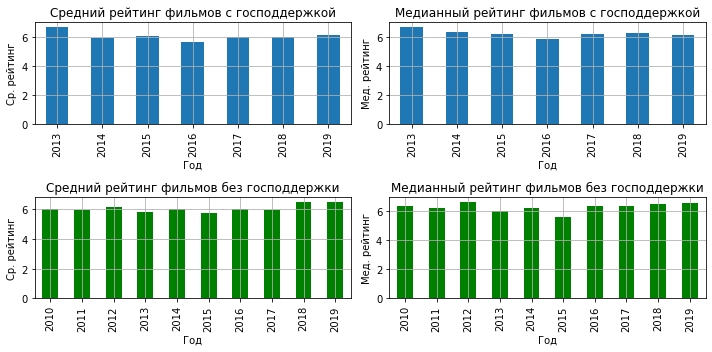

In [128]:
# Построим график среднего и медианного рейтинга фильмов с господдержкой и без по годам
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))

# Средний рейтинг для фильмов с господдержкой
ax = (
supported_films.groupby('year')['ratings'].agg('mean')
.plot(
        kind='bar',
        y = 'ratings',
        legend=False,
        figsize=(10,5),
        grid = True,
        title='Средний рейтинг фильмов с господдержкой',
        ax=axes[0,0]
     )
)
ax.set_ylabel('Ср. рейтинг')
ax.set_xlabel('Год');

# Медианный рейтинг для фильмов с господдержкой
ax = (
supported_films.groupby('year')['ratings'].agg('median')
.plot(
        kind='bar',
        y = 'ratings',
        legend=False,
        figsize=(10,5),
        grid = True,
        title='Медианный рейтинг фильмов с господдержкой',
        ax=axes[0,1]
     )
)
ax.set_ylabel('Мед. рейтинг')
ax.set_xlabel('Год');

# Средний рейтинг для фильмов без господдержки

ax = (
data.query('budget==0 and main_country=="Россия"').groupby('year')['ratings'].agg('mean')
.plot(
        kind='bar',
        y = 'ratings',
        legend=False,
        figsize=(10,5),
        grid = True,
        title='Средний рейтинг фильмов без господдержки',
        ax=axes[1,0],
        color='green'
     )
)
ax.set_ylabel('Ср. рейтинг')
ax.set_xlabel('Год');

# Медианный рейтинг для фильмов без господдержки

ax = (
data.query('budget==0 and main_country=="Россия"').groupby('year')['ratings'].agg('median')
.plot(
        kind='bar',
        y = 'ratings',
        legend=False,
        figsize=(10,5),
        grid = True,
        title='Медианный рейтинг фильмов без господдержки',
        ax=axes[1,1],
        color='green'
     )
)
ax.set_ylabel('Мед. рейтинг')
ax.set_xlabel('Год');


plt.tight_layout();

In [129]:
# Также построим сводную таблицу средних рейтингов по источникам финансирования и годам
data.pivot_table(index='financing_source', columns='year', values='ratings', aggfunc='mean')

year,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019
financing_source,,,,,,,,,,
Министерство культуры и Фонд кино,NaN,NaN,NaN,6.70,5.96,6.06,5.69,6.05,6.04,6.18
Частное финансирование,6.72,6.53,6.55,6.51,6.53,6.34,6.40,6.35,6.41,6.52


* В целом медианные и средние рейтинги близки, оба показателя отражают одинаковую динамику по годам. 
* Из приведенных расчетов видно, что рейтинг фильмов без госсподержки выше рейтинга фильмов с господдержкой (за исключением одного года - 2013)
* Как было известно их предыдущих разделов анализа, средний рейтинг составляет 6.48. Исходя из этого, рейтинг фильмов без господдержки в основном превышает или почти равен средниму показателю по выборке. По фильмам с господдержкой рейтинг превысил средний только в 2013 г., в остальные года он был значительно ниже.

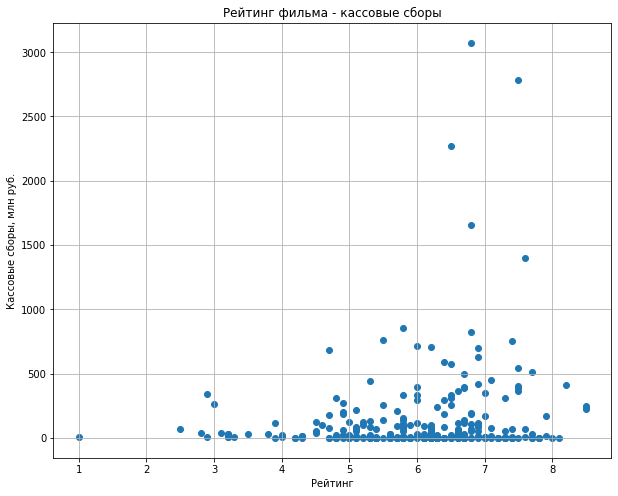

In [130]:
# Построим диаграмму рессеяния для пары рейтинг - сборы
plt.figure(figsize=(10,8))
plt.scatter(supported_films['ratings'],supported_films['box_office_mln'])
plt.xlabel('Рейтинг')
plt.ylabel('Кассовые сборы, млн руб.')
plt.title('Рейтинг фильма - кассовые сборы')
plt.grid(True);

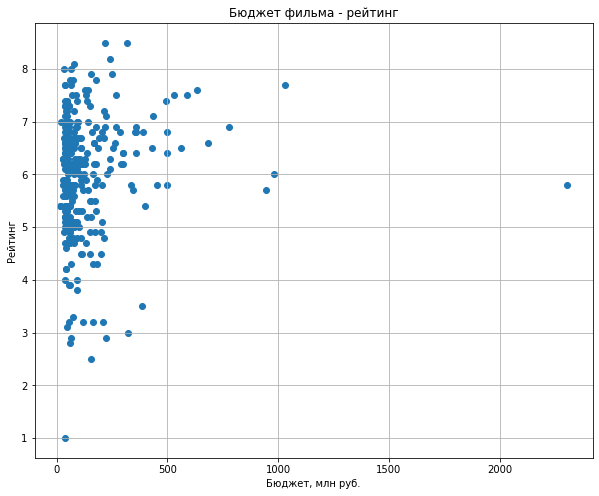

In [131]:
# Построим диаграмму рессеяния для пары бюджет - рейтинг
plt.figure(figsize=(10,8))
plt.scatter(supported_films['budget'],supported_films['ratings'])
plt.xlabel('Бюджет, млн руб.')
plt.ylabel('Рейтинг')
plt.title('Бюджет фильма - рейтинг')
plt.grid(True);

Явной связи между бюджетом фильма и его рейтингом, а также между рейтингом и кассовыми сборами не прослеживается.

In [132]:
# Топ 10 рейтинговых режиссеров
supported_films.groupby('main_director')['ratings'].agg('mean').sort_values(ascending = False).head(10)

main_director
Р.Прыгунов     8.20
А.Атанесян     8.10
А.Попова       8.00
К.Оганисян     7.90
И.Шахназаров   7.80
В.Татарский    7.80
А.Учитель      7.70
А.Игудин       7.70
М.Михайлова    7.70
Н.Лебедев      7.60
Name: ratings, dtype: float64

Из данного рейтинга видно, что список наиболее коммерчески успешных режиссеров полностью отличается от списка режиссеров с наибольшим рейтингом. Логичнее было б чтоб оба рейтинга были похожи.

In [133]:
#Топ 10 низкорейтинговых режиссеров
supported_films.query('~ratings.isna()').groupby('main_director')['ratings'].agg('mean').sort_values(ascending = False).tail(10)

main_director
И.Евланникова                       3.50
Э.Веливис                           3.20
К.Кузин                             3.20
А.Лукьянчиков                       3.20
С.Саркисов                          3.20
Т.Корнев                            3.10
Ф.Коршунов при участии П.Мирзоева   2.90
О.Лопато                            2.80
Т.Кеосаян                           2.50
М.Свешников                         1.00
Name: ratings, dtype: float64

In [134]:
# Топ жанров по рейтингу
supported_films.groupby('main_genre')['ratings'].agg('mean').sort_values(ascending = False).head(10)

main_genre
криминал    7.50
детский     7.12
спорт       6.93
биография   6.90
детектив    6.76
мюзикл      6.55
военный     6.47
драма       6.39
боевик      6.34
фэнтези     6.09
Name: ratings, dtype: float64

In [135]:
# Топ жанров по антирейтингу
supported_films.query('~ratings.isna()').groupby('main_genre')['ratings'].agg('mean').sort_values(ascending = False).tail(10)

main_genre
мультфильм    5.91
мелодрама     5.91
приключения   5.87
фантастика    5.84
триллер       5.70
реальное ТВ   5.60
комедия       5.52
семейный      5.41
история       5.35
ужасы         5.20
Name: ratings, dtype: float64

Фильмы с участием господдержки получают:
   * наиболее высокие рейтинги в категориях "криминал", "детский", "спорт"
   * наиболее низкие рейтинги в категориях "ужасы", "история", "семейный"

#### Возрастные ограничения фильмов с господдержкой

In [136]:
# Количество фильмов по категориям возрастных ограничений
supported_films.groupby('age_restr_shrt')['title'].count()

age_restr_shrt
«0+»       8
«12+»    103
«16+»    118
«18+»     27
«6+»      59
Name: title, dtype: int64

In [137]:
supported_films.groupby('age_group')['title'].count()

age_group
Взрослые             27
Дети и подростки    288
Name: title, dtype: int64

91% снимаемых фильмов рассчитаны на молодую аудиторию (до 18 лет)

In [138]:
# Рейтинг фильмов по категориям возрастных ограничений
supported_films.groupby('age_restr_shrt')['ratings'].mean()

age_restr_shrt
«0+»    6.41
«12+»   6.05
«16+»   5.93
«18+»   6.26
«6+»    5.97
Name: ratings, dtype: float64

In [139]:
# Рейтинг фильмов по категориям возрастных ограничений
supported_films.groupby('age_group')['ratings'].mean()

age_group
Взрослые           6.26
Дети и подростки   5.99
Name: ratings, dtype: float64

Наиболее высокий рейтинг у фильмов в категории 0+, наиболее низкий у фильмов категории 16+. В целом средний рейтинг фильмов 18- близок к 6, при среднем рейтинге по датасету 6.48. У фильмов для взрослых по сравнению с фильмами для детей и подростков рейтинг выше - 6.26, но также ниже среднего рейтинга по датасету

In [140]:
# Сборы в прокате, прибыль и рентабельность фильмов по категориям возрастных ограничений
age_categories_profit = supported_films.pivot_table(index='age_restr_shrt', 
                            values=['support_budget','budget','box_office_mln'],
                            aggfunc='sum')

age_categories_profit['profit'] = age_categories_profit['box_office_mln'] - age_categories_profit['budget']
age_categories_profit['profitability'] = age_categories_profit['profit'] / age_categories_profit['budget']

age_categories_profit

,box_office_mln,budget,support_budget,profit,profitability
age_restr_shrt,,,,,
«0+»,552.93,902.98,273.52,-350.05,-0.39
«12+»,18707.71,15251.95,7463.39,3455.76,0.23
«16+»,6715.76,11513.59,5241.05,-4797.83,-0.42
«18+»,558.20,2250.84,953.35,-1692.64,-0.75
«6+»,12805.57,12320.91,4877.40,484.67,0.04


Из всех категорий фильмов по возрастным ограничениям прибыльными являются только фильмы 12+ (+23%) и 6+ (+4%). В абсолютном выражении самые убыточные категории 16+ и 18+. По показателю рентабельности самые убыточные - фильмы 18+ (-75%)

**Выводы по исследованию фильмов с государственной поддержкой**

<u>Выделение средств на поддержку кино:</u>
* За весь период представленный в датасете выделено 18.8 млрд рублей господдержки отечественных фильмов
* 81% - невозвратная поддержка
* Данные по господдержке фильмов имеются начиная с 2013 г., резкий рост поддержки произошел в 2015 г. В 2015-2019 гг объем господдержки варьируется в диапозоне 3 - 5 млрд руб / год без какого-то явного тренда.
* Доля господдержки варьируется в диапозоне 38-55% от бюджетов фильмов, наименьшая доля зафиксирована в 2019 году (38%)
* Режиссеры: топ-3 режиссера по объемам получаемой гос. поддержки: Н.Хомерики (600М), Ф.Бондарчук(500М), А.Кравчук(500М) 
* Жанры: на первом месте  по объемам господдержки драмы, затем комедии, на третьем месте мультфильмы. Доля поддержки варьируется в основном 40-50%.
* Фильмы: на первом месте по поддержке фильмы "Вторжение" и "Союз спасения"(по 500 млн руб. каждый) с долей поддержки в бюджете фильма 51-53%.

<u>Сборы и окупаемость фильмов с господдержкой:</u>
* Убыток от фильмов с господдержкой за все время -2.9 млрд рублей, рентабельность: -7%
* Прибыль от фильмов с государственной поддержкой была получена только в 2017 и 2018 гг., в остальные периоды получен убыток. Какого-то явного тренда не прослеживается. Наибольший убыток был получен в 2019 г (-4.3 млрд руб, рентабельность -34%). Наибольшая прибыль в 2017 г (+3.8 млрд руб., рентабельность +54%).
* Наиболее прибыльными оказались комедии - прибыль 6.3 млрд рублей (+106% рентабельности), на втором месте спорт (прибыль меньше, но рентабельность +318%), на третьем месте ужасы.
* В группу наименее успешных и наиболее убыточных фильмов попали приключения, драма, фантастика, фэнтази и детективы. Можно предположить, что фильмы в данной категории не выдерживают конкуренции с фильмами голливудского производства.
* Топ коммерчески успешных режиссеров:
    1. Клим Шипенко - снял фильмы Вызов, Холоп (1,2), Текст
    2. Антон Мегердичев - Метро, Движение вверх, Бывшие, Темный мир, Бой с тенью 2
    3. Алексей Сидоров - фильмография пересекается с Мегердичевым
    4. Дмитрий Дьяченко - Последний богатырь (3 части), Чебурашка
    5. Олег Трофим - фильмы о майоре Громе

* Топ коммерчески неуспешных режиссеров:
    1. Олег Степченко - Вий, Тайна печати дракона,
    2. Андрей Кончаловский
    3. Алексей Учитель - Матильда, Цой, Летучий корабль
    4. Александр Мельник - серия малоизвестных фильмов
    5. Павел Лунгин - Остров

<u>Рейтинги фильмов с господдержкой:</u>
* В целом медианные и средние рейтинги близки. 
* Из приведенных расчетов видно, что рейтинг фильмов без госсподержки выше рейтинга фильмов с господдержкой (за исключение одного года - 2013)
* Как было известно их предыдущих разделов анализа, средний/медианный рейтинг составляет 6.48. Исходя из этого, рейтинг фильмов без господдержки в основном превышает или приближается к среднему показателю по выборке. По фильмам с господдержкой рейтинг превысил средний только в 2013 г., в остальные года он был значительно ниже.
* Явной связи между бюджетом фильма и его рейтингом, а также между рейтингом и кассовыми сборами не прослеживается.
* Список наиболее коммерчески успешных режиссеров полностью отличается от списка режиссеров с наибольшим рейтингом. 
* Фильмы с участием господдержки получают:
   * наиболее высокие рейтинги в категориях "криминал", "детский", "спорт"
   * наиболее низкие рейтинги в категориях "ужасы", "история", "семейный"

<u>Возрастные ограничения фильмов с господдержкой:</u>
* 91% снимаемых фильмов рассчитаны на молодую аудиторию (до 18 лет)
* Наиболее высокий рейтинг у фильмов в категории 0+, наиболее низкий у фильмов категории 16+. В целом средний рейтинг фильмов 18- близок к 6, при среднем рейтинге по датасету 6.48. У фильмов для взрослых по сравнению с фильмами для детей и подростков рейтинг выше - 6.28, но также ниже среднего рейтинга по датасету
* Из всех категорий фильмов по возрастным ограничениям прибыльными являются только фильмы 12+ (+23%) и 6+ (+4%). В абсолютном выражении самые убыточные категории 16+ и 18+. По показателю рентабельности самые убыточные - фильмы 18+ (-75%)
* Можно предположить, что перекос в сторону съемок фильмов для детей, а также рентабельность таких фильмов в категориях 12+, 6+, связана с тем, что в кинотеатры родители чаще ходят с детьми и поэтому приносят большую кассу по сравнению с фильмами 18+. Для проверки этой версии необходима информация по поло-возрастным характеристикам посетителей российских кинотеатров.

### Шаг 5. Напишите общий вывод

**Подготовка данных к анализу**

По заданию объединены два датасета. По условию необходимо было, чтобы все объекты из таблицы movies вошли в получившийся датафрейм - для это датафремы были объединены способом "left", то есть ко всем объектам таблицы movies (левая таблица) присоединялись объекты из таблицы shows на основании совпадения прокатного удостоверения. Этот способ как раз и позволяет выполнить поставленное условие.


**Предобработка данных**

* Заполнены пропуски по категориальным полям ("заглушками"), по фильмам без господдержки данные по поддержке и бюджету заполнены нулями. По полям рейтинга и кассовых сборов пропуски не заполнялись.
* По полю кассовых сборов обнаружено большое количество аномальных данных, вероятно проблемы с размерностью, их природа и закономерность неясна. Изменения по данному полю не производились.
* Удалены неявные дубликаты по номеру прокатного удостоверения, явных (полных) дублей не обнаружено.
* По результатам предобработки датасет сократился на 0.25%


**Исследовательский анализ данных**

* Динамика количества фильмов рассчитанная по количеству прокатных удостоверений и по наличию информации о прокате существенно отличаются за период 2010-2014 гг. Данных по фильмам с информацией о прокате в 2010-2014 гг. существенно меньше, чем в последующие периоды.

* В 2010-2014 гг аномально низкие значения величины сборов, что вероятно связано с ошибками в размерности величин.

* Во всех годах присутствует существенная разница между средним и медианным значением кассовых сборов в российских кинотеатрах. Везде среднее значительно выше медианы. Это объясняется тем, что на медиану оказывает большое количество малых значений величины сборов, в то время как среднеарифмитечская зависит от всех значений в выборке и искажается экстремально высокими значениями в большую сторону.

* В 2018-2019 гг существенно сократились сборы фильмов в категории 0+, при этом количество премьер осталось примерно на одном уровне
* Сборы фильмов в категориях 12+, 16+, 6+ колеблются примерно на одном уровне
* Сборы фильмов 18+ медленно растут
* Динамика количества премьер по обеим категориям ("Взрослые" и "Дети и подростки") схожа, с разницей в абсолютном количестве премьер (фильмов для детей и подростков снимается больше примерно в 2-3 раза.
* Кассовые сборы фильмов для детей и подростков стабильно находятся на отметке около 40 млрд руб ежегодно, без какой либо явной тенденции к росту или снижению.

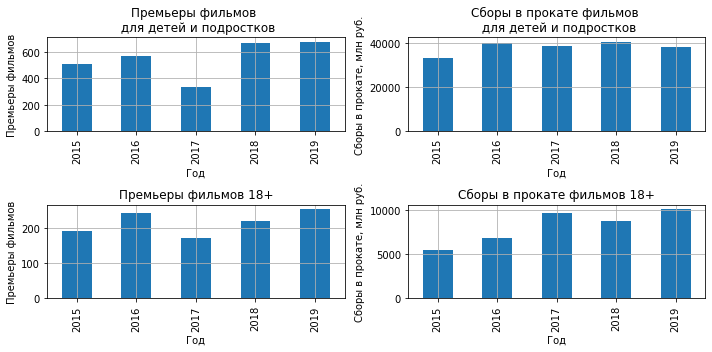
* На графике кассовых сборов фильмов 18+ заметен тренд к увеличению суммы сборов, так начиная с 2015 года сборы выросли с ~5 млрд до 10 млрд руб. в 2019 г.


**Исследование фильмов, которые получили государственную поддержку**

<u>Выделение средств на поддержку кино:</u>
* За весь период представленный в датасете выделено 18.8 млрд рублей господдержки отечественных фильмов
* 81% - невозвратная поддержка
* Данные по господдержке фильмов имеются начиная с 2013 г., резкий рост поддержки произошел в 2015 г. В 2015-2019 гг объем господдержки варьируется в диапозоне 3 - 5 млрд руб / год без какого-то явного тренда.
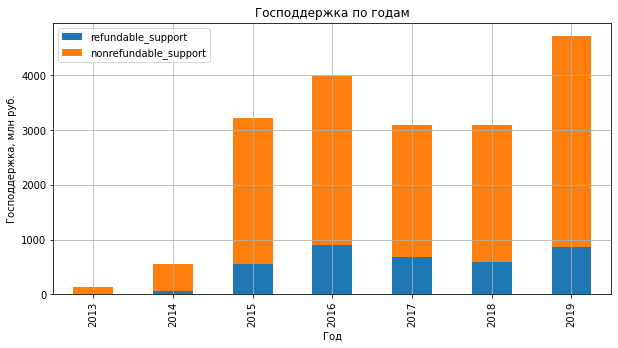
* Доля господдержки варьируется в диапозоне 38-55% от бюджетов фильмов, наименьшая доля зафиксирована в 2019 году (38%)
* Режиссеры: топ-3 режиссера по объемам получаемой гос. поддержки: Н.Хомерики (600М), Ф.Бондарчук(500М), А.Кравчук(500М) 
* Жанры: на первом месте  по объемам господдержки драмы, затем комедии, на третьем месте мультфильмы. Доля поддержки варьируется в основном 40-50%.
* Фильмы: на первом месте по поддержке фильмы "Вторжение" и "Союз спасения"(по 500 млн руб. каждый) с долей поддержки в бюджете фильма 51-53%.

<u>Сборы и окупаемость фильмов с господдержкой:</u>
* Убыток от фильмов с господдержкой за все время -2.9 млрд рублей, рентабельность: -7%
* Прибыль от фильмов с государственной поддержкой была получена только в 2017 и 2018 гг., в остальные периоды получен убыток. Какого-то явного тренда не прослеживается. Наибольший убыток был получен в 2019 г (-4.3 млрд руб, рентабельность -34%). Наибольшая прибыль в 2017 г (+3.8 млрд руб., рентабельность +54%).
* Наиболее прибыльными оказались комедии - прибыль 6.3 млрд рублей (+106% рентабельности), на втором месте спорт (прибыль меньше, но рентабельность +318%), на третьем месте ужасы.
* В группу наименее успешных и наиболее убыточных фильмов попали приключения, драма, фантастика, фэнтази и детективы. Можно предположить, что фильмы в данной категории не выдерживают конкуренции с фильмами голливудского производства.
* Топ коммерчески успешных режиссеров:
    1. Клим Шипенко - снял фильмы Вызов, Холоп (1,2), Текст
    2. Антон Мегердичев - Метро, Движение вверх, Бывшие, Темный мир, Бой с тенью 2
    3. Алексей Сидоров - фильмография пересекается с Мегердичевым
    4. Дмитрий Дьяченко - Последний богатырь (3 части), Чебурашка
    5. Олег Трофим - фильмы о майоре Громе

* Топ коммерчески неуспешных режиссеров:
    1. Олег Степченко - Вий, Тайна печати дракона,
    2. Андрей Кончаловский
    3. Алексей Учитель - Матильда, Цой, Летучий корабль
    4. Александр Мельник - серия малоизвестных фильмов
    5. Павел Лунгин - Остров

<u>Рейтинги фильмов с господдержкой:</u>
* В целом медианные и средние рейтинги близки. 
* Из приведенных расчетов видно, что рейтинг фильмов без госсподержки выше рейтинга фильмов с господдержкой (за исключение одного года - 2013)
* Как было известно их предыдущих разделов анализа, средний/медианный рейтинг составляет 6.48. Исходя из этого, рейтинг фильмов без господдержки в основном превышает или приближается к среднему показателю по выборке. По фильмам с господдержкой рейтинг превысил средний только в 2013 г., в остальные года он был значительно ниже.
* Явной связи между бюджетом фильма и его рейтингом, а также между рейтингом и кассовыми сборами не прослеживается.
* Список наиболее коммерчески успешных режиссеров полностью отличается от списка режиссеров с наибольшим рейтингом. 
* Фильмы с участием господдержки получают:
   * наиболее высокие рейтинги в категориях "криминал", "детский", "спорт"
   * наиболее низкие рейтинги в категориях "ужасы", "история", "семейный"

<u>Возрастные ограничения фильмов с господдержкой:</u>
* 91% снимаемых фильмов рассчитаны на молодую аудиторию (до 18 лет)
* Наиболее высокий рейтинг у фильмов в категории 0+, наиболее низкий у фильмов категории 16+. В целом средний рейтинг фильмов 18- близок к 6, при среднем рейтинге по датасету 6.48. У фильмов для взрослых по сравнению с фильмами для детей и подростков рейтинг выше - 6.28, но также ниже среднего рейтинга по датасету
* Из всех категорий фильмов по возрастным ограничениям прибыльными являются только фильмы 12+ (+23%) и 6+ (+4%). В абсолютном выражении самые убыточные категории 16+ и 18+. По показателю рентабельности самые убыточные - фильмы 18+ (-75%)
* Можно предположить, что перекос в сторону съемок фильмов для детей, а также рентабельность таких фильмов в категориях 12+, 6+, связана с тем, что в кинотеатры родители чаще ходят с детьми и поэтому приносят большую кассу по сравнению с фильмами 18+. Для проверки этой версии необходима информация по поло-возрастным характеристикам посетителей российских кинотеатров.

Общие рекомендации по результатам анализа:

* Текущая поддержка отечественного кинематографа убыточна. Большая доля господдержки приходится на убыточные фильмы с рейтингом ниже среднего. Необходимо поддерживать режиссеров, фильмы которых высоко ценятся зрителями, это может дать мультпликативный эффект - повысить кассовые сборы.
* Принимать решения о выделении поддержки исходя из предпочтений зрителей по жанрам.
* Необходимо создавать условия для рыночной конкуренции в кинопроизводстве без участия государственной поддержки. Рынок (продюссеры, режиссеры и кинопрокатчики) сам подстроится под потребности зрителя и начнет производить востребованные и коммерчески успешные фильмы.